# Note to Marker
The python kernel used for this project is Python 3.12.12

Citations and references appear in the cells of reference


# 1 - Domain Specific area and objectives of the project (200 - 500 words)

My domain interest is in the circular economy, specifically the recovery of precious metals from electronic waste.  A major challenge in any recycling or circular economy project is the act of sorting (90% of the recovery effort based on my personal experience).  Scrap electronics circuit boards contain a mixture of components, materials and value, and these need to be separated before precious metal recovery can occur. Sorting can be performed manually, mechanically, by hydro separation, or robotic methods. My particular interest is in robotic sorting, where a robot arm identifies (computer vision), picks, separates and sorts electronic components as one of the initial steps for precious metal recovery.

With this domain in mind, I began a search for a dataset that met the project requirements.  Although I found many electronics and robotics datasets, many were aimed at image classification or object recognition (precisely 'my domain') rather than linear regression.  The dataset that I have chosen is a UC Irvine dataset: [Condition Monitoring of Hydraulic Systems](https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+systems). [1] This dataset is not directly related to e-waste sorting, but it is closely related to robotic automations and control. Robotic and automated sorting systems depend on reliable motion (360,x,y,z axis), actuation, cooling and mechanical control. The device measured in the UC Irvine study was a hydraulic test rig and is a useful proxy for understanding how sensor data can be used to predict machine performance.

The objective of this project is to use Linear Regression to predict a continuous hydraulic system performance measure such as cooling efficiency or 'systems efficiency factor', from sensor readings including pressure, flow, temperature, vibration and motor power.  A by-product of measuring  these variables is the identification of faulty, or close to failure sensors, so that they can be maintained or replaced.  Improving efficiency may also lead to an improved ROI and add to an organizations bottom line through the use of inferred maintenance leading to improved uptime and system performance.

Linear Regression is suitable because the dataset contains numerical sensor values and numerical target values, and the project requirements require identifying variables with an approximately linear trendline. I will use visualization techniques to inspect the dataset such as scatter plots, correlelations and trendlines, before selecting predictors.

The project will preprocess the raw data (multiple files) into cycle level features, normalize values, and train a Linear Regression model with a subsequent evaluation for accuracy and error.  The intention is to understand how the model can identify how sensor readings are associated with hydraulic effienciency.  

In the wider circular economy context, this supports the challenge of robotic reliability.  Many of these systems run 24 hours a day with millions of movements so identifying loss of efficiency, prediction of maintenance or component replacement, contributes to improved uptime and to overall efficiency of recovery operations.

## Goal:
### To predict hydraulic system efficiency from sensor data to support robotic sorting in e-waste precious metal recover

[1]: Helwig,N., et al. (2018) UC Irvine. Last accessed June 21, 2026. "Condition Monitoring of Hydraulic Systems"


# 2 - Dataset Description (200-500 words)
The dataset selected for this project is the UC Irvine [Condition Monitoring of Hydraulic Systems](https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+systems). [1] created by Helwig, Pignanelli, and Schütze and donated to the UCI Machine Learning Repository [2] in 2018.  The metadata associated with the repository states that 'the dataset was experimentally obtained with a hydraulic test rig' that was subjectd to a "load cycle of 60 seconds where measurements of pressure, volume flows and temperatures were taken while the hydraulic components (cooler, valve, pump and actuator) were quantitatively varied"[1].

The dataset is licenced under a [Creative Commons Attribution 4.0 International](https://creativecommons.org/licenses/by/4.0/legalcode)[3] which allows for the sharing and adaptation of the dataset for any purpose, provided that the appropriate credit is given.

The dataset contains 2,205 instance where each instance is one 60 second load cycle. The number of features is 43,680 based on 14 sensors, and is significant due to their sheer number of features.  When I understood the challenge of working with this number of attributes I felt anxious but decided to remain with the dataset and the challenges that it presents.  The dataset comprises of multiple tab-delimited text files where each file represents a single sensor. 

The file structure is a matrix style where a row represents a 60 second cycle, and the columns represent data points. The immediate challenge will be to merge these into a single file (DataFrame) and then figure out how to simplify and normalize the resulting data.

The variables (attributes/features) represent pressure sensors, volume flow sensors, temperature sensors, vibration and motor power. Targets include cooling efficiency, cooling power, and system efficiency factor. The dataset is continuous and numeric with a combination of numbers and percentages.

The 14 sensors are identified by the name of their data files and there are 5 groupings:

- Pressure Sensors PS1 to PS6.  Measured in bars at 100Hz 
- Motor Power EPS1. Measured in Watts at 100hz
- Volume Flow FS1, FS2. Measured in liters per minute at 100Hz
- Temperature TS1 to TS4. Measured in °C at 1Hz
- Vibration VS1. 

In terms of missing values the dataset metadata states that there are no missing values [1]

The dataset is suitable for a Linear Regression project (it is listed as such [1]) and there are three possible targets: (1) hydraulic system efficiency, (2) cooling efficiency or (3) cooling power. A Linear Regression model could test whether a change in sensor readings correlate with system performance in a linear fashion.  

[1]: Helwig,N., et al. (2018) UC Irvine. Last accessed June 21, 2026. "Condition Monitoring of Hydraulic Systems". https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+systems
[2]: UC Irvine. Machine Learning Repository.  Last accessed June 21, 2026. https://archive.ics.uci.edu/
[3]: Creative Commons. CC By 4.0 Attribution 4.0 International Legal Code. Last accessed June 21, 2026. https://creativecommons.org/licenses/by/4.0/legalcode



# 3. Data Preparation
This is a large section.  Primarily due to the number of files that are needed to be processed as well as both visual and programmatic analysis of the data.

The input consists of 17 tab delimited data files, a profile file, and 2 metadata files (description and documentation).
Each type of file will be progressively analysed and explained as this section progresses.

The output will be a sensor dataframe containing statistical measures for each sensor cycle that can be used for machine learning purposes in later sections of the project.

There will be some data visualization appearing in this section as I progress through the process of file combination and normalization.  

In [82]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# %matplotlib inline # check this!

from pathlib import Path
import zipfile

In [2]:
# Display settings
# These are my own personal preferences
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

The original dataset is downloaded as a zip file and stored in the /data/original directory.
Doing this means that the original zip can be submitted along with the project and then
extracted using the next few steps

The original zip download uses a '+' delimiting each word.  When I downloaded I renamed the file

from: condition+monitoring+of+hydraulic+systems.zip

to: condition_monitoring_of_hydraulic-systems.zip

In [54]:
# TODO - Create these paths if they do not exist
# Set the data source paths
project_dir = Path.cwd()
# print(project_dir)
data_dir = project_dir / "data" / "extracted"
zip_dir = project_dir / "data" / "original"
dataframe_dir = project_dir / "data" / "dataframes"
original_path = zip_dir / "condition_monitoring_of_hydraulic-systems.zip"
extraction_path = data_dir / "condition_monitoring_of_hydraulic-systems"
visualization_dir = project_dir / "data" / "visualizations"
PROCESSED_DIR = project_dir / "data" / "processed"

The dataset is distributed as a ZIP archive. After extraction, the folder contains multiple tab-delimited text files. The data is not supplied as a single tidy CSV file, so loading and combining the files is part of the preprocessing task.

In [4]:
# delete any files that exist in the extraction_path prior to extraction
for item in extraction_path.iterdir():
    item.unlink()

In [5]:
# Extract the zip file
with zipfile.ZipFile(original_path, "r") as zip_ref:
    zip_ref.extractall(extraction_path)

In my experience it is best to step through each and every step and automate as much as possible.

I will first create a dataframe to store information about each file extracted including:

- filename
- relative file path (important per UoL instructions to use relative paths)
- file size (mb)
- file extension (should be .txt)

In [6]:
# recursive search for all (.*) files using rglob
all_data_files = sorted(extraction_path.rglob("*"))

data_file_inventory = [] # initialise an empty python list to store files

In [7]:
# Add dict entries containing file metadata for each extracted file to the data_file_inventory_list
for file in all_data_files:
    if file.is_file():
        data_file_inventory.append({
            "file_name": file.name,
            "relative_path": str(file.relative_to(extraction_path)),
            "extension": file.suffix,
            "size": file.stat().st_size / (1024 * 1024) # convert file size to mb
        })

In [8]:
# convert the data_file_inventory_list to a pandas dataframe
data_file_inventory_df = pd.DataFrame(data_file_inventory)
data_file_inventory_df

,file_name,relative_path,extension,size
0,CE.txt,CE.txt,.txt,0.869289
1,CP.txt,CP.txt,.txt,0.743239
2,description.txt,description.txt,.txt,0.003857
3,documentation.txt,documentation.txt,.txt,0.004500
4,EPS1.txt,EPS1.txt,.txt,83.362192
5,FS1.txt,FS1.txt,.txt,7.230688
6,FS2.txt,FS2.txt,.txt,7.888721
7,profile.txt,profile.txt,.txt,0.029751
8,PS1.txt,PS1.txt,.txt,87.158100
9,PS2.txt,PS2.txt,.txt,78.557597


The dataset is a combination of sensor reading files and additional files that describe the dataset.
The data for these files came directly from the dataset page on the UC Irvine site:
[variable information](https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+systems)

- Pressure files are prefixed with 'PS', unit is bars, sampling rate is 100Hz
- Motor Power files are prefixed with 'EPS'
- Volume flow files are prefixed with 'FS'
- Temperature files are prefixed with 'TS'
- Vibration files are prefixed with 'VS'
- Cooling Efficiency filesare prefixed with 'CE'
- Cooling Power files are prefixed with 'CP'
- Efficiency Factor files are prefixed with 'SE'  #TODO: is this the target?

Each file has rows that represent a 60 second cycle.  For each cycle, readings are taken based on the sampling rate. So, a 100 Hz sampling rate is 100 readings per second.  For the Pressure Sensor "PS1" file this means that that there are 2,205 cycles each with 100 samples per second for 60 seconds: 100 * 60 = 6,000 samples per cycle.

This equates to 2,205 * 6,000 = 132,300 samples

The profile.txt file has the associated 'machine conditions' for each cycle. The profile.txt file 'could' be used as a taeget file to understand, for example, if the combination of pressure, flow, temperature, vibration and motor power readings could be used to predicy cooler efficiency.  At this stage, I do not know enough about the dataset to explore this question but it is something that will be reviewed once I begin asking some questions of the datasets themselves.

profile.txt : TODO: Add more detail
- Column 0: Cooler Condition.
- Column 1: Valve Condition.
- Column 2: Internal Pump Leakage. 
- Column 3: Hydraulic Accumulator Pressure
- Column 4: Stable Flag (0 or 1).


In [9]:
# I needed a way to prevent metadata files being loaded so I created a dictionary
# to store a list of files that I can load into a single dataframe
sensor_metadata = {
    "PS1": {"quantity": "Pressure", "unit": "bar", "sampling_rate_hz": 100},
    "PS2": {"quantity": "Pressure", "unit": "bar", "sampling_rate_hz": 100},
    "PS3": {"quantity": "Pressure", "unit": "bar", "sampling_rate_hz": 100},
    "PS4": {"quantity": "Pressure", "unit": "bar", "sampling_rate_hz": 100},
    "PS5": {"quantity": "Pressure", "unit": "bar", "sampling_rate_hz": 100},
    "PS6": {"quantity": "Pressure", "unit": "bar", "sampling_rate_hz": 100},
    "EPS1": {"quantity": "Motor power", "unit": "W", "sampling_rate_hz": 100},
    "FS1": {"quantity": "Volume flow", "unit": "l/min", "sampling_rate_hz": 10},
    "FS2": {"quantity": "Volume flow", "unit": "l/min", "sampling_rate_hz": 10},
    "TS1": {"quantity": "Temperature", "unit": "C", "sampling_rate_hz": 1},
    "TS2": {"quantity": "Temperature", "unit": "C", "sampling_rate_hz": 1},
    "TS3": {"quantity": "Temperature", "unit": "C", "sampling_rate_hz": 1},
    "TS4": {"quantity": "Temperature", "unit": "C", "sampling_rate_hz": 1},
    "VS1": {"quantity": "Vibration", "unit": "mm/s", "sampling_rate_hz": 1},
    "CE": {"quantity": "Cooling efficiency", "unit": "%", "sampling_rate_hz": 1},
    "CP": {"quantity": "Cooling power", "unit": "kW", "sampling_rate_hz": 1},
    "SE": {"quantity": "Efficiency factor", "unit": "%", "sampling_rate_hz": 1},
}

Create a loading summary to record the number of rows, columns, total cells and missing values for each file. This confirms whether the files have been read correctly and whether they align by operating cycle.

In [10]:
# Load the datasets (about 10 seconds)

txt_files = sorted(extraction_path.glob("*.txt"))

data_files = {}
load_summary = []

for file in txt_files:
    name = file.stem
    try:
        df = pd.read_csv(file, sep="\t", header=None)
        data_files[name] = df

        load_summary.append({
            "file": file.name,
            "key": name,
            "rows" : df.shape[0],
            "columns": df.shape[1],
            "total_cells": df.shape[0] * df.shape[1],
            "missing_values": int(df.isna().sum().sum()),
            "numeric_columns": int(df.select_dtypes(include=[np.number]).shape[1])
        })

    except Exception as e:
       load_summary.append({
            "file": file.name,
            "key": name,
            "rows" : None,
            "columns": None,
            "total_cells": None,
            "missing_values": None,
            "numeric_columns": None,
            "error": str(e)
        }) 
       
load_summary_df = pd.DataFrame(load_summary)
load_summary_df

,file,key,rows,columns,total_cells,missing_values,numeric_columns,error
0,CE.txt,CE,2205.0,60.0,132300.0,0.0,60.0,NaN
1,CP.txt,CP,2205.0,60.0,132300.0,0.0,60.0,NaN
2,description.txt,description,NaN,NaN,NaN,NaN,NaN,'utf-8' codec can't decode byte 0xfc in positi...
3,documentation.txt,documentation,NaN,NaN,NaN,NaN,NaN,'utf-8' codec can't decode byte 0xfc in positi...
4,EPS1.txt,EPS1,2205.0,6000.0,13230000.0,0.0,6000.0,NaN
5,FS1.txt,FS1,2205.0,600.0,1323000.0,0.0,600.0,NaN
6,FS2.txt,FS2,2205.0,600.0,1323000.0,0.0,600.0,NaN
7,profile.txt,profile,2205.0,5.0,11025.0,0.0,5.0,NaN
8,PS1.txt,PS1,2205.0,6000.0,13230000.0,0.0,6000.0,NaN
9,PS2.txt,PS2,2205.0,6000.0,13230000.0,0.0,6000.0,NaN


In [11]:
# Save the dataframe
load_summary_df.to_csv(dataframe_dir / "load_summary.csv", index = False)

The profile file is treated differently from the raw sensor files because it contains one row per operating cycle rather than in-cycle sampled sensor readings. 

These columns describe the known condition of hydraulic components and can be used for grouping, filtering or later classification tasks. They can also help interpret whether efficiency changes are associated with degraded component states.

In [12]:
# process the profile file.
profile = data_files["profile"].copy()

profile.columns=[
    "cooler_condition",
    "valve_condition",
    "pump_leakage",
    "hydraulic_accumulator",
    "stable_flag"
]

profile.head()

,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


In [13]:
# use describe to get see some file statistics
profile.describe()

,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,41.240816,90.693878,0.669388,107.199546,0.342857
std,42.383143,10.681802,0.817233,16.435848,0.474772
min,3.000000,73.000000,0.000000,90.000000,0.000000
25%,3.000000,80.000000,0.000000,90.000000,0.000000
50%,20.000000,100.000000,0.000000,100.000000,0.000000
75%,100.000000,100.000000,1.000000,130.000000,1.000000
max,100.000000,100.000000,2.000000,130.000000,1.000000


In [14]:
for col in profile.columns:
    print("\n", col)
    print(profile[col].value_counts().sort_index())


 cooler_condition
cooler_condition
3      732
20     732
100    741
Name: count, dtype: int64

 valve_condition
valve_condition
73      360
80      360
90      360
100    1125
Name: count, dtype: int64

 pump_leakage
pump_leakage
0    1221
1     492
2     492
Name: count, dtype: int64

 hydraulic_accumulator
hydraulic_accumulator
90     808
100    399
115    399
130    599
Name: count, dtype: int64

 stable_flag
stable_flag
0    1449
1     756
Name: count, dtype: int64


The results above are interesting.  Each sensor profile produces a small number of values (3 for example in the cooler_condition profile).  At this point in time I do not fully understand the implications of each result and will hopefully obtain a decent understanding as I work through the datasets.

The row alignment check (cell below) verifies that each file contains the same number of operating cycles. 

Important because later preprocessing will combine cycle-level summaries from each sensor file into one modelling table.

In [15]:
# check that every file has the same number of rows (per sensor) as found in profile.txt.
# This ensures a one to one mapping between sensor cycles and machine assessment found in profile.txt
row_check = []
expected_rows = profile.shape[0]

for name, df in data_files.items():
    row_check.append({
        "file_key": name,
        "rows": df.shape[0],
        "matches_profile_rows" : df.shape[0] == expected_rows
    })

row_check_df = pd.DataFrame(row_check)
row_check_df

,file_key,rows,matches_profile_rows
0,CE,2205,True
1,CP,2205,True
2,EPS1,2205,True
3,FS1,2205,True
4,FS2,2205,True
5,profile,2205,True
6,PS1,2205,True
7,PS2,2205,True
8,PS3,2205,True
9,PS4,2205,True


In [16]:
# save the row_check_df
row_check_df.to_csv(dataframe_dir / "row_check", index=False)

## Section 3 - Data Preparation - Programmatic data checks

Data Quality

The quality summary checks whether each file is numeric, whether missing values are present, and whether the range of values appears reasonable. Although UCI identifies the dataset as having no missing values, this check is still necessary because imported files may contain parsing issues, blank columns or formatting problems.

In [17]:
data_quality_summary = []

for name, df in data_files.items():
    # Ensure all number fields are either numeric or NaN
    numeric_df = df.apply(pd.to_numeric, errors="coerce")

    # convert to a numpy array (improved performance) and flatten to a list using ravel
    values = numeric_df.to_numpy().ravel()
    # remove NaNs and keep the array clean and numeric only
    values = values[~np.isnan(values)]

    data_quality_summary.append({
        "file_key" : name, 
        "rows" : df.shape[0],
        "columns" : df.shape[1],
        "missing_values": int(numeric_df.isna().sum().sum()),
        "min": np.min(values) if len(values) > 0 else np.nan,
        "max": np.max(values) if len(values) > 0 else np.nan,
        "mean": np.mean(values) if len(values) > 0 else np.nan,
        "std": np.std(values) if len(values) > 0 else np.nan,
    })

data_quality_summary_df = pd.DataFrame(data_quality_summary)
data_quality_summary_df

,file_key,rows,columns,missing_values,min,max,mean,std
0,CE,2205,60,0,17.042,48.777,31.299077,11.577906
1,CP,2205,60,0,1.016,2.909,1.808399,0.279326
2,EPS1,2205,6000,0,2097.800,2995.200,2495.509203,218.222229
3,FS1,2205,600,0,0.000,20.479,6.198549,3.213826
4,FS2,2205,600,0,8.764,10.453,9.649453,0.449489
5,profile,2205,5,0,0.000,130.000,48.029297,49.122090
6,PS1,2205,6000,0,133.130,191.920,160.485315,16.133330
7,PS2,2205,6000,0,0.000,167.770,109.379906,48.103172
8,PS3,2205,6000,0,0.000,18.828,1.753227,0.934707
9,PS4,2205,6000,0,0.000,10.266,2.600266,4.297607


The above dataframe is a good result.  As per the UC Irvine documentation there are no missing values which indicates that this is a very good quality dataset.


In [18]:
# save the dataframe
data_quality_summary_df.to_csv(dataframe_dir / "data_quality_summary.csv", index = False)

In [20]:
# Create a per cycle statistical summary of the features for every sensor file
# There are thousands of features so reducing the number by caculating the 
# statistical '5' makes sense prior to performing Linear Regression.
# Calculate mean, standard deviation, median, min, max for each column in each file

def summarise_sensor_file(df, prefix):
    # Make sure that all data is numeric and if not 'coerce' to a NaN
    numeric_df = df.apply(pd.to_numeric, errors="coerce")
    
    # calcuate summary statistics; axis = 1 is column wise across rows
    summary = pd.DataFrame({
        f"{prefix}_mean": numeric_df.mean(axis=1),
        f"{prefix}_std": numeric_df.std(axis=1),
        f"{prefix}_min": numeric_df.min(axis=1),
        f"{prefix}_max": numeric_df.max(axis=1),
        f"{prefix}_median": numeric_df.median(axis=1)
    })
    
    return summary

In [21]:
# for each file in the data_files dictionary calcuated the statistical '5' for each row of data
feature_tables = []

for name, df in data_files.items():
    if name != "profile":
        feature_tables.append(summarise_sensor_file(df, name))

features = pd.concat(feature_tables, axis=1)
features.head()

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median
0,39.601350,6.370535,28.866,47.438,40.6755,1.862750,0.279385,1.383,2.188,1.9240,2538.929167,185.616121,2339.8,2951.6,2479.8,6.709815,3.015428,0.0,18.710,7.836,10.304592,0.091772,10.148,10.446,10.327,160.673492,13.939309,145.83,191.51,156.25,109.466914,47.114508,0.0,156.99,129.365,1.991475,0.945705,0.0,10.039,2.297,0.0,0.0,0.0,0.0,0.0,9.842170,0.088154,9.681,10.016,9.844,9.728097,0.085366,9.568,9.887,9.733,59.157183,23.763984,0.0,79.568,68.5145,35.621983,0.308230,35.156,36.152,35.5720,40.978767,0.154302,40.773,41.250,40.9630,38.471017,0.084659,38.316,38.613,38.4960,31.745250,1.116478,30.363,33.594,31.576,0.576950,0.027078,0.532,0.624,0.5770
1,25.786433,1.686129,23.320,29.208,25.3855,1.255550,0.074605,1.147,1.414,1.2340,2531.498900,189.940089,2332.0,2947.4,2470.0,6.715315,3.006248,0.0,18.712,7.853,10.403098,0.019162,10.352,10.453,10.403,160.603320,14.118967,145.73,191.47,156.06,109.354890,47.045611,0.0,157.56,129.385,1.976234,0.941967,0.0,9.992,2.273,0.0,0.0,0.0,0.0,0.0,9.635142,0.038392,9.557,9.745,9.632,9.529488,0.036316,9.454,9.637,9.526,59.335617,23.857918,0.0,80.441,68.5360,36.676967,0.585740,35.648,37.488,36.7675,41.532767,0.338234,41.031,42.105,41.5180,38.978967,0.176921,38.668,39.254,38.9845,34.493867,0.435312,33.648,35.148,34.553,0.565850,0.027241,0.524,0.626,0.5595
2,22.218233,0.638345,21.220,23.554,22.1040,1.113217,0.023263,1.076,1.159,1.1095,2519.928000,190.736850,2318.6,2939.8,2457.4,6.718522,3.014248,0.0,18.698,7.847,10.366250,0.026361,10.296,10.443,10.367,160.347720,14.192619,145.37,191.41,155.72,109.158845,46.992060,0.0,156.97,129.325,1.972224,0.943501,0.0,10.914,2.273,0.0,0.0,0.0,0.0,0.0,9.530548,0.035817,9.455,9.640,9.528,9.427949,0.036031,9.348,9.536,9.425,59.543150,23.923381,0.0,80.824,68.8530,37.880800,0.559169,36.879,38.621,38.0235,42.442450,0.390588,41.832,43.039,42.4235,39.631950,0.251133,39.234,40.062,39.6270,35.646150,0.293889,35.098,36.141,35.635,0.576533,0.036729,0.529,0.662,0.5620
3,20.459817,0.455755,19.673,21.565,20.4805,1.062150,0.024621,1.022,1.107,1.0660,2511.541633,191.270607,2310.8,2929.6,2448.0,6.720565,3.020176,0.0,18.896,7.843,10.302678,0.026750,10.241,10.382,10.302,160.188088,14.227803,145.14,191.34,155.56,109.064807,46.972221,0.0,156.44,128.865,1.946575,0.935534,0.0,10.297,2.242,0.0,0.0,0.0,0.0,0.0,9.438827,0.037069,9.363,9.535,9.436,9.337430,0.037375,9.257,9.431,9.335,59.794900,24.023005,0.0,80.930,69.0060,38.879050,0.516176,37.887,39.473,39.0550,43.403983,0.398476,42.805,43.988,43.3650,40.403383,0.285434,40.023,40.934,40.3420,36.579467,0.262397,36.105,36.988,36.635,0.569267,0.033464,0.527,0.645,0.5550
4,19.787017,0.290156,19.133,20.460,19.7985,1.070467,0.021477,1.016,1.106,1.0725,2503.449500,191.258369,2301.8,2923.8,2440.6,6.690308,3.011550,0.0,18.876,7.831,10.237750,0.029170,10.179,10.312,10.236,160.000472,14.276434,144.95,191.41,155.34,108.931434,46.874946,0.0,158.13,129.000,1.922707,0.930335,0.0,11.102,2.219,0.0,0.0,0.0,0.0,0.0,9.358762,0.029779,9.290,9.443,9.358,9.260636,0.028592,9.195,9.342,9.260,59.455267,23.972262,0.0,81.100,69.0130,39.803917,0.535374,38.789,40.391,39.9670,44.332750,0.372769,43.742,44.887,44.3355,41.310550,0.293579,40.859,41.777,41.3400,37.427900,0.239571,36.992,37.781,37.439,0.577367,0.033484,0.524,0.660,0.5760


There seems to be an issue with the PS4 calculations as there are no results. Below I check the tail, and a random selection of rows, and see that there are results for these columns so everything checks out.

In [23]:
features.shape

(2205, 85)

In [ ]:
# Specifically looking at PS4 columns. Looking for non-zero data
features.tail()

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median
2200,46.628517,0.237772,46.242,47.092,46.6335,2.160600,0.018171,2.127,2.196,2.1615,2543.911033,187.530212,2346.0,2953.2,2481.6,6.689930,3.001512,0.0,20.228,7.8395,10.184515,0.013701,10.147,10.224,10.185,161.227572,13.987129,146.69,191.81,156.59,109.779581,47.253414,0.0,167.49,130.300,2.001438,0.931535,0.0,9.445,2.320,10.202473,0.023118,10.130,10.264,10.202,9.972037,0.022277,9.910,10.028,9.970,9.850361,0.021802,9.790,9.905,9.849,59.03310,23.635352,0.0,77.752,68.4505,35.313783,0.141893,35.000,35.516,35.4100,40.874800,0.071999,40.727,40.977,40.879,38.269267,0.066279,38.168,38.371,38.262,30.404733,0.032142,30.363,30.488,30.395,0.550833,0.029820,0.512,0.618,0.5485
2201,46.689817,0.392929,45.762,47.486,46.6510,2.151450,0.023372,2.094,2.200,2.1485,2543.411333,187.062031,2345.8,2950.8,2481.6,6.692182,3.005831,0.0,20.308,7.8340,10.177767,0.014669,10.133,10.233,10.178,161.206070,14.001418,146.64,191.81,156.55,109.787481,47.247815,0.0,167.27,130.275,1.998781,0.930958,0.0,9.398,2.320,10.197919,0.023339,10.127,10.255,10.198,9.966184,0.022023,9.901,10.014,9.965,9.844854,0.021932,9.777,9.894,9.844,59.06800,23.638396,0.0,77.592,68.4075,35.321600,0.137743,34.988,35.516,35.3765,40.868883,0.071279,40.707,40.977,40.871,38.268250,0.072038,38.148,38.418,38.262,30.416233,0.037951,30.367,30.488,30.395,0.547483,0.021463,0.507,0.584,0.5425
2202,46.472300,0.462510,45.683,47.206,46.7005,2.143300,0.027183,2.099,2.188,2.1425,2542.729767,186.846232,2345.8,2949.4,2480.6,6.693277,2.991333,0.0,20.071,7.8330,10.176172,0.014749,10.127,10.225,10.177,161.192120,13.988350,146.63,191.84,156.56,109.756174,47.244805,0.0,167.34,130.250,1.993436,0.929445,0.0,9.492,2.305,10.196824,0.023725,10.116,10.255,10.196,9.964329,0.022527,9.898,10.019,9.964,9.842628,0.022094,9.777,9.896,9.842,59.13235,23.633405,0.0,77.773,68.3130,35.319183,0.152040,34.984,35.520,35.4060,40.875950,0.073286,40.719,40.977,40.879,38.246367,0.080508,38.156,38.371,38.242,30.426250,0.045413,30.367,30.496,30.406,0.545233,0.024047,0.502,0.597,0.5440
2203,46.544967,0.242202,45.846,47.001,46.5490,2.148483,0.017777,2.107,2.188,2.1480,2544.046333,186.799816,2346.0,2951.6,2481.8,6.684128,3.003983,0.0,20.280,7.8235,10.178353,0.014619,10.129,10.230,10.180,161.208917,13.985248,146.65,191.77,156.58,109.793884,47.240806,0.0,167.52,130.300,2.007077,0.933360,0.0,9.469,2.328,10.198588,0.024640,10.116,10.257,10.198,9.968232,0.023517,9.898,10.022,9.967,9.846690,0.023185,9.767,9.900,9.846,58.97080,23.600817,0.0,77.568,68.3500,35.324767,0.158769,35.000,35.531,35.4120,40.876067,0.063998,40.742,40.977,40.893,38.245733,0.075174,38.145,38.363,38.246,30.414283,0.038725,30.363,30.488,30.402,0.537017,0.017652,0.502,0.585,0.5350
2204,46.647933,0.250113,46.144,47.109,46.6035,2.157050,0.021039,2.126,2.194,2.1495,2543.818300,186.529535,2344.0,2951.4,2483.4,6.692302,3.007413,0.0,20.395,7.8370,10.183393,0.015373,10.120,10.233,10.184,161.217128,13.984674,146.57,191.69,156.60,109.792177,47.238665,0.0,167.34,130.340,2.002690,0.932842,0.0,9.344,2.320,10.203126,0.024331,10.121,10.262,10.204,9.973638,0.023194,9.903,10.024,9.972,9.851949,0.022552,9.785,9.900,9.851,59.05390,23.627226,0.0,77.748,68.3705,35.322233,0.149859,35.008,35.531,35.3945,40.859400,0.065621,40.715,40.973,40.840,38.248917,0.074163,38.148,38.391,38.19

In [ ]:
# Specifically looking at PS4 columns. Looking for non-zero data
features.sample(n=10, random_state=12)

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median
1770,47.478367,0.240925,47.058,47.910,47.4350,2.166750,0.020220,2.137,2.205,2.1585,2535.333267,187.563238,2333.8,2942.0,2471.8,6.696547,3.081109,0.0,19.838,7.8265,10.165998,0.014540,10.120,10.214,10.1670,161.178820,14.036045,146.40,191.66,156.420,109.295862,47.549242,0.0,167.41,129.995,2.000362,0.958002,0.0,9.711,2.3200,10.075224,0.023693,10.002,10.134,10.075,9.843133,0.021606,9.785,9.891,9.842,9.727801,0.021800,9.663,9.774,9.7270,58.975067,23.777712,0.0,79.944,68.6735,36.177117,0.146840,35.840,36.344,36.2360,41.777483,0.099490,41.570,41.910,41.7835,39.059283,0.077659,38.965,39.207,39.0270,31.151000,0.012917,31.121,31.172,31.156,0.556517,0.021316,0.512,0.605,0.5520
2157,46.552283,0.240802,46.146,47.069,46.5085,2.156350,0.020447,2.126,2.208,2.1575,2540.132800,188.993691,2337.8,2947.4,2475.6,6.650810,3.053481,0.0,20.479,7.8205,10.165867,0.015680,10.108,10.209,10.1670,161.388168,14.148946,146.51,191.71,156.490,109.113553,47.811254,0.0,167.41,130.180,1.983542,0.940929,0.0,9.547,2.3125,10.157635,0.024069,10.078,10.225,10.157,9.929860,0.021962,9.865,9.979,9.929,9.811053,0.022487,9.746,9.861,9.8110,58.160800,24.259112,0.0,77.865,68.6780,35.574733,0.157877,35.234,35.758,35.6560,41.210350,0.102018,41.039,41.332,41.2340,38.503200,0.071986,38.426,38.687,38.5040,30.639433,0.011942,30.605,30.668,30.641,0.550367,0.020504,0.511,0.592,0.5485
1939,47.247783,0.349453,46.684,47.833,47.2665,2.160200,0.023027,2.120,2.204,2.1570,2537.572900,187.056957,2339.8,2947.4,2475.8,6.700850,3.000863,0.0,20.014,7.8250,10.147363,0.014867,10.097,10.194,10.1480,160.928550,14.039139,146.39,191.59,156.260,109.541939,47.150625,0.0,167.23,130.060,1.992401,0.934851,0.0,9.695,2.3050,10.063539,0.023907,9.984,10.127,10.062,9.832569,0.021793,9.764,9.884,9.832,9.718450,0.021835,9.654,9.767,9.7180,59.225383,23.693258,0.0,78.532,68.3650,36.318583,0.165935,36.000,36.512,36.3240,41.981450,0.077914,41.883,42.098,41.9820,39.214317,0.063289,39.160,39.355,39.1800,31.318267,0.038213,31.273,31.398,31.305,0.544033,0.022250,0.507,0.595,0.5380
1777,47.541983,0.230882,47.182,47.911,47.4955,2.173867,0.020512,2.140,2.212,2.1690,2542.304900,189.303948,2339.8,2955.8,2479.4,6.707283,3.066085,0.0,19.662,7.8275,10.169550,0.015018,10.111,10.219,10.1700,161.057978,14.009320,146.35,191.68,156.360,109.493626,47.307011,0.0,167.31,129.895,2.017172,0.963133,0.0,9.937,2.3280,10.076509,0.023931,9.997,10.136,10.077,9.845817,0.021413,9.785,9.892,9.845,9.730061,0.021666,9.664,9.780,9.7290,59.123800,23.729485,0.0,79.443,68.4460,36.228400,0.142387,35.926,36.426,36.2460,41.832900,0.069868,41.656,41.910,41.8790,39.083167,0.073812,38.965,39.195,39.0860,31.151867,0.017874,31.066,31.184,31.156,0.544367,0.019307,0.509,0.595,0.5415
1760,47.542767,0.390184,46.961,48.298,47.4950,2.166767,0.025983,2.126,2.225,2.1645,2537.930100,188.559540,2336.0,2947.6,2473.6,6.661267,3.065367,0.0,20.467,7.8290,10.164648,0.015031,10.120,10.203,10.1650,161.266635,14.103332,146.42,191.71,156.410,109.039319,47.803434,0.0,167.33,129.985,1.999694,0.962753,0.0,9.695,2.3200,10.082252,0.023707,10.002,10.141,10.083,9.851321,0.021934,9.790,9.903,9.850,9.735169,0.021857,9.670,9.788,9.7340,58.176167,24.249861,0.0,79.958,68.6740,36.091167,0.153523,35.754,36.262,36.1385,41.654633,0.084986,41.520,41.801,41.6465,38.940050,0

The processed dataset combines all cycle-level sensor summaries with the condition information from `profile.txt`. Each row now represents one hydraulic operating cycle, and each column represents either a derived sensor feature or a known condition variable.

In [26]:
# Combine the features dataframe with data from the profile file
model_data = pd.concat([features, profile], axis=1)

model_data.head()

model_data.head()

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
0,39.601350,6.370535,28.866,47.438,40.6755,1.862750,0.279385,1.383,2.188,1.9240,2538.929167,185.616121,2339.8,2951.6,2479.8,6.709815,3.015428,0.0,18.710,7.836,10.304592,0.091772,10.148,10.446,10.327,160.673492,13.939309,145.83,191.51,156.25,109.466914,47.114508,0.0,156.99,129.365,1.991475,0.945705,0.0,10.039,2.297,0.0,0.0,0.0,0.0,0.0,9.842170,0.088154,9.681,10.016,9.844,9.728097,0.085366,9.568,9.887,9.733,59.157183,23.763984,0.0,79.568,68.5145,35.621983,0.308230,35.156,36.152,35.5720,40.978767,0.154302,40.773,41.250,40.9630,38.471017,0.084659,38.316,38.613,38.4960,31.745250,1.116478,30.363,33.594,31.576,0.576950,0.027078,0.532,0.624,0.5770,3,100,0,130,1
1,25.786433,1.686129,23.320,29.208,25.3855,1.255550,0.074605,1.147,1.414,1.2340,2531.498900,189.940089,2332.0,2947.4,2470.0,6.715315,3.006248,0.0,18.712,7.853,10.403098,0.019162,10.352,10.453,10.403,160.603320,14.118967,145.73,191.47,156.06,109.354890,47.045611,0.0,157.56,129.385,1.976234,0.941967,0.0,9.992,2.273,0.0,0.0,0.0,0.0,0.0,9.635142,0.038392,9.557,9.745,9.632,9.529488,0.036316,9.454,9.637,9.526,59.335617,23.857918,0.0,80.441,68.5360,36.676967,0.585740,35.648,37.488,36.7675,41.532767,0.338234,41.031,42.105,41.5180,38.978967,0.176921,38.668,39.254,38.9845,34.493867,0.435312,33.648,35.148,34.553,0.565850,0.027241,0.524,0.626,0.5595,3,100,0,130,1
2,22.218233,0.638345,21.220,23.554,22.1040,1.113217,0.023263,1.076,1.159,1.1095,2519.928000,190.736850,2318.6,2939.8,2457.4,6.718522,3.014248,0.0,18.698,7.847,10.366250,0.026361,10.296,10.443,10.367,160.347720,14.192619,145.37,191.41,155.72,109.158845,46.992060,0.0,156.97,129.325,1.972224,0.943501,0.0,10.914,2.273,0.0,0.0,0.0,0.0,0.0,9.530548,0.035817,9.455,9.640,9.528,9.427949,0.036031,9.348,9.536,9.425,59.543150,23.923381,0.0,80.824,68.8530,37.880800,0.559169,36.879,38.621,38.0235,42.442450,0.390588,41.832,43.039,42.4235,39.631950,0.251133,39.234,40.062,39.6270,35.646150,0.293889,35.098,36.141,35.635,0.576533,0.036729,0.529,0.662,0.5620,3,100,0,130,1
3,20.459817,0.455755,19.673,21.565,20.4805,1.062150,0.024621,1.022,1.107,1.0660,2511.541633,191.270607,2310.8,2929.6,2448.0,6.720565,3.020176,0.0,18.896,7.843,10.302678,0.026750,10.241,10.382,10.302,160.188088,14.227803,145.14,191.34,155.56,109.064807,46.972221,0.0,156.44,128.865,1.946575,0.935534,0.0,10.297,2.242,0.0,0.0,0.0,0.0,0.0,9.438827,0.037069,9.363,9.535,9.436,9.337430,0.037375,9.257,9.431,9.335,59.794900,24.023005,0.0,80.930,69.0060,38.879050,0.516176,37.887,39.473,39.0550,43.403983,0.398476,42.805,43.988,43.3650,40.403383,0.285434,40.023,40.934,40.3420,36.579467,0.262397,36.105,36.988,36.635,0.569267,0.033464,0.527,0.645,0.5550,3,100,0,130,1
4,19.787017,0.290156,19.133,20.460,19.7985,1.070467,0.021477,1.016,1.106,1.0725,2503.449500,191.258369,2301.8,2923.8,2440.6,6.690308,3.011550,0.0,18.876,7.831,10.237750,0.029170,10.179,10.312,10.236,160.000472,14.276434,144.95,191.41,155.34,108.931434,46.874946,0.0,158.13,129.000,1.922707,0.930335,0.0,11.102,2.219,0.0,0.0,0.0,0.0,0.0,9.358762,0.029779,9.290,9.443,9.358,9.260636,0.028592,9.195,9.342,9.260,59.455267,23.972262,0.0,81.100,69.0130,39.803917,0.535374,38.789,40.391,39.9670,44.332750,0.372769,43.742,44.887,44.3355,41.31055

In [ ]:
# save this dataframe.  We use this for the Linear Regression.
model_data.to_csv(dataframe_dir / "cycle_level_model_data.csv", index=False)

Perform some exploratory analysis of the model data to further understand the data.  The basics are info and describe.

In [28]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 90 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CE_mean                2205 non-null   float64
 1   CE_std                 2205 non-null   float64
 2   CE_min                 2205 non-null   float64
 3   CE_max                 2205 non-null   float64
 4   CE_median              2205 non-null   float64
 5   CP_mean                2205 non-null   float64
 6   CP_std                 2205 non-null   float64
 7   CP_min                 2205 non-null   float64
 8   CP_max                 2205 non-null   float64
 9   CP_median              2205 non-null   float64
 10  EPS1_mean              2205 non-null   float64
 11  EPS1_std               2205 non-null   float64
 12  EPS1_min               2205 non-null   float64
 13  EPS1_max               2205 non-null   float64
 14  EPS1_median            2205 non-null   float64
 15  FS1_

In [ ]:
# I transpose the rows to columns.  This makes it easier to see the statistical 5 across the dataset
model_data.describe().T

,count,mean,std,min,25%,50%,75%,max
CE_mean,2205.0,31.299077,11.575330,17.555983,20.084650,27.392533,46.677383,47.903667
CE_std,2205.0,0.287325,0.199760,0.063164,0.217363,0.264125,0.329684,6.370535
CE_min,2205.0,30.785665,11.583481,17.042000,19.513000,26.862000,46.168000,47.626000
CE_max,2205.0,31.880312,11.602740,18.142000,20.694000,27.983000,47.272000,48.777000
CE_median,2205.0,31.287446,11.570829,17.501000,20.083000,27.363500,46.648500,47.945000
...,...,...,...,...,...,...,...,...
cooler_condition,2205.0,41.240816,42.383143,3.000000,3.000000,20.000000,100.000000,100.000000
valve_condition,2205.0,90.693878,10.681802,73.000000,80.000000,100.000000,100.000000,100.000000
pump_leakage,2205.0,0.669388,0.817233,0.000000,0.000000,0.000000,1.000000,2.000000
hydraulic_accumulator,2205.0,107.199546,16.435848,90.000000,90.000000,100.000000,130.000000,130.000000


In [36]:
# create a summarised dataset of the model_data to inspect for missing values, data types, uniqueness.
# this is the last step in determining that the model data is of a sufficient quality
processed_summary = pd.DataFrame({
    "column": model_data.columns,
    "data_type": model_data.dtypes.astype(str),
    "missing_values": model_data.isna().sum().values,
    "unique_values": model_data.nunique().values
})

processed_summary.to_csv(dataframe_dir / "processed_data_summary.csv", index=False)
processed_summary

,column,data_type,missing_values,unique_values
CE_mean,CE_mean,float64,0,2200
CE_std,CE_std,float64,0,2205
CE_min,CE_min,float64,0,1696
CE_max,CE_max,float64,0,1739
CE_median,CE_median,float64,0,1987
...,...,...,...,...
cooler_condition,cooler_condition,int64,0,3
valve_condition,valve_condition,int64,0,4
pump_leakage,pump_leakage,int64,0,3
hydraulic_accumulator,hydraulic_accumulator,int64,0,4


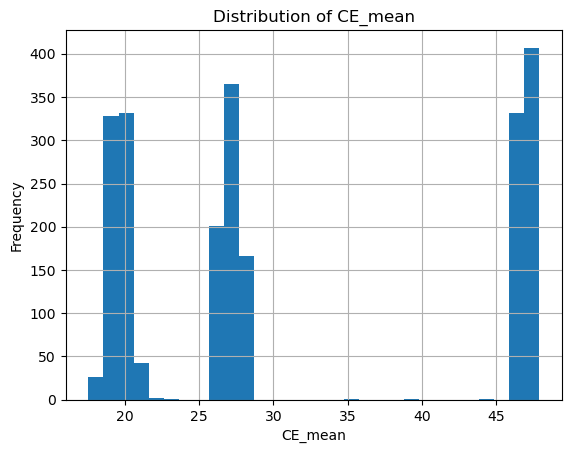

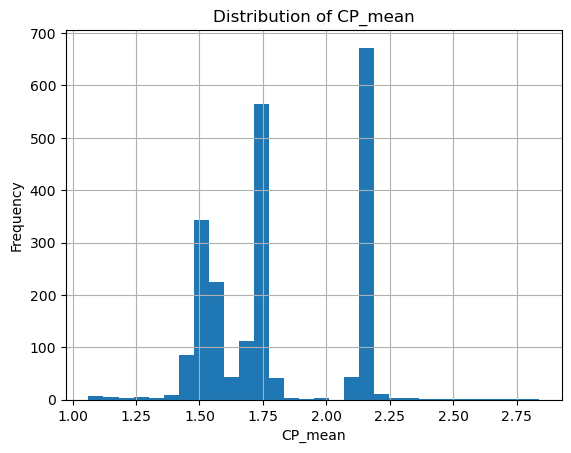

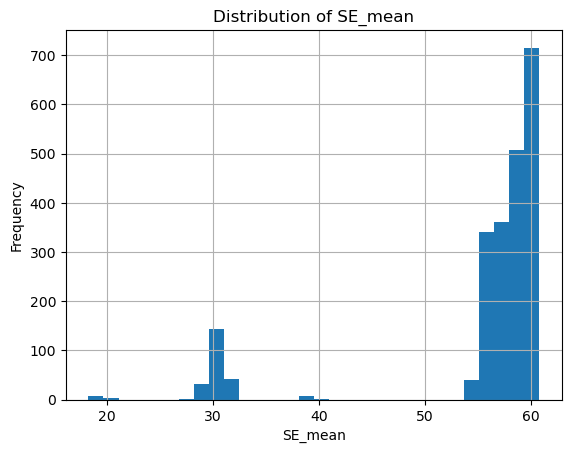

In [ ]:
# Perform a basic visualization of the summary data
# I am specifically targeting cooling efficiency (CE), cooling power (CP) and system efficiency (SE) factor
# more analysis via visualization will occur in the next stage.  For now this is exploratory only.
target_candidates = ["CE_mean", "CP_mean", "SE_mean"]

for target in target_candidates:
    if target in model_data.columns:
        plt.figure()
        model_data[target].hist(bins=30)
        plt.title(f"Distribution of {target}")
        plt.xlabel(target)
        plt.ylabel("Frequency")
        plt.savefig(visualization_dir / f"distribution_{target}.png", bbox_inches="tight")
        plt.show()

The histogram plots above show that there are multiple mean clusters for these three targets.  At this stage I am ok with what I am seeing as I am not sure that my level of understanding of how these clusters might affect Linear Regression.  I am looking forward to seeing this play out.


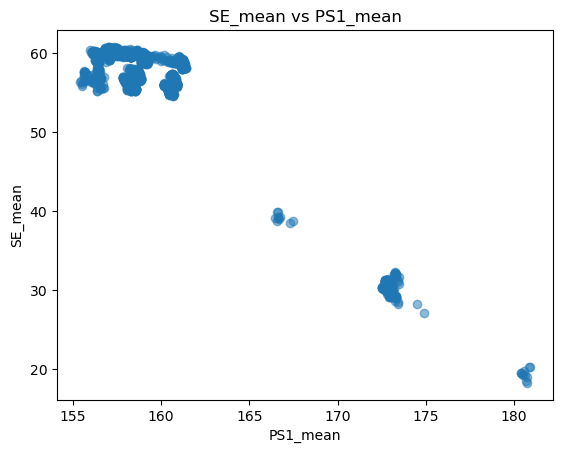

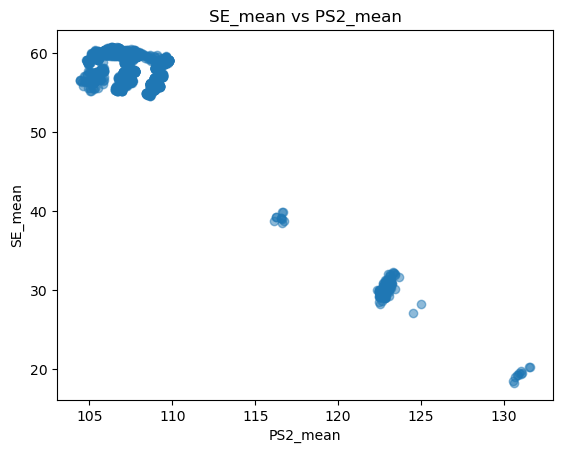

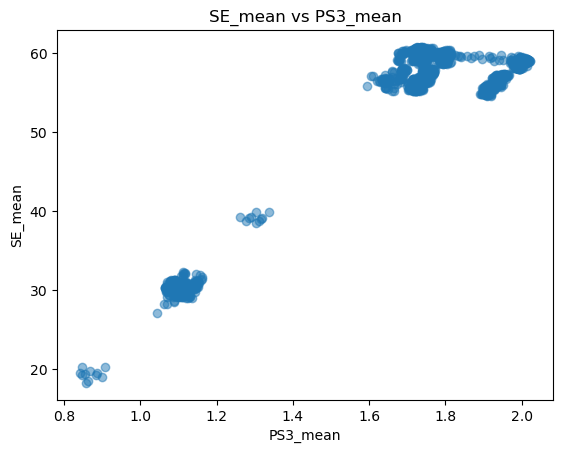

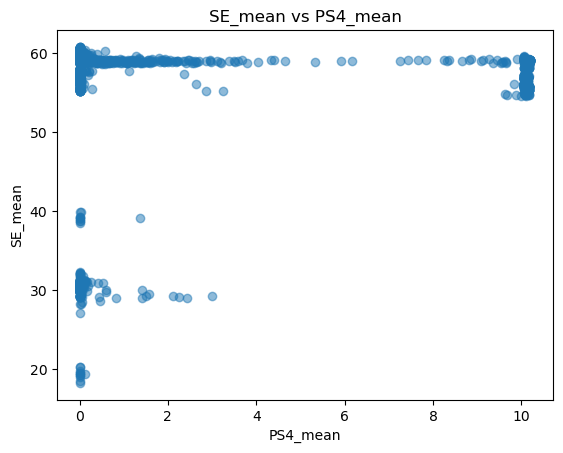

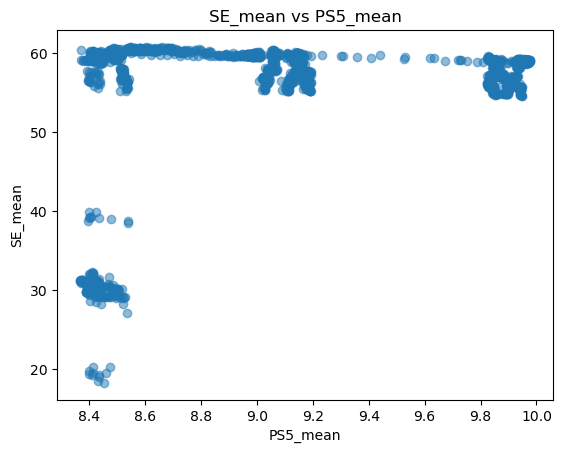

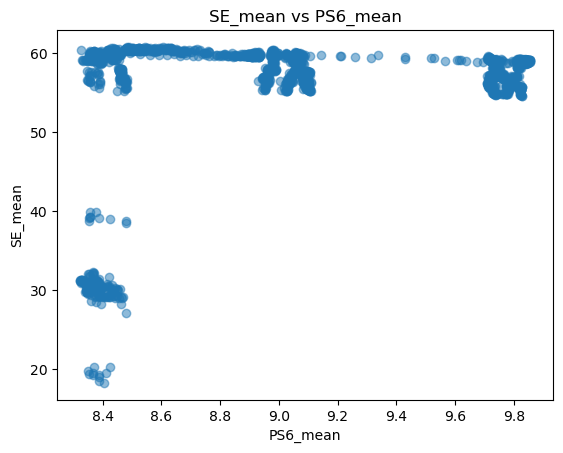

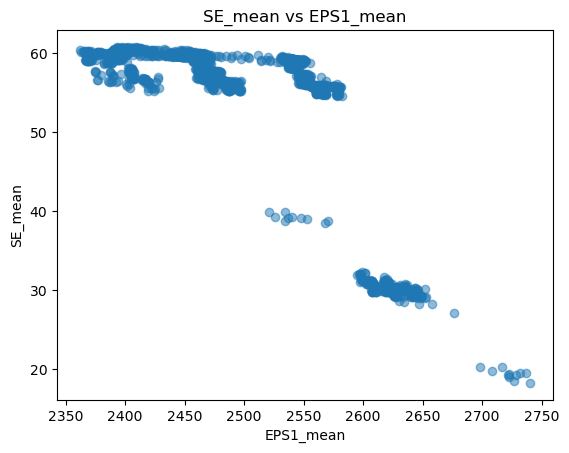

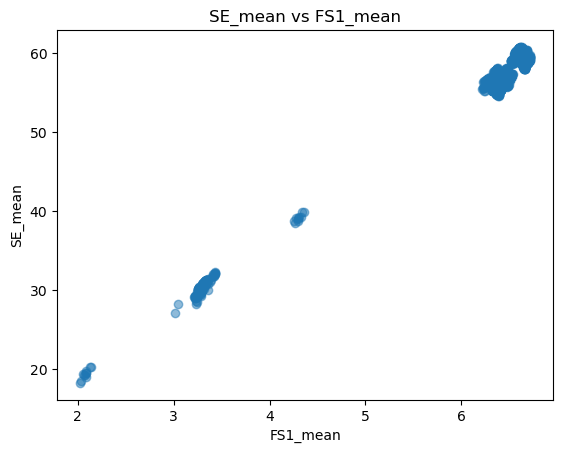

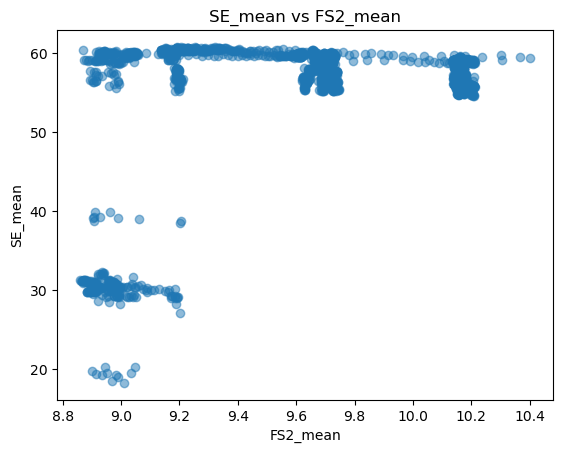

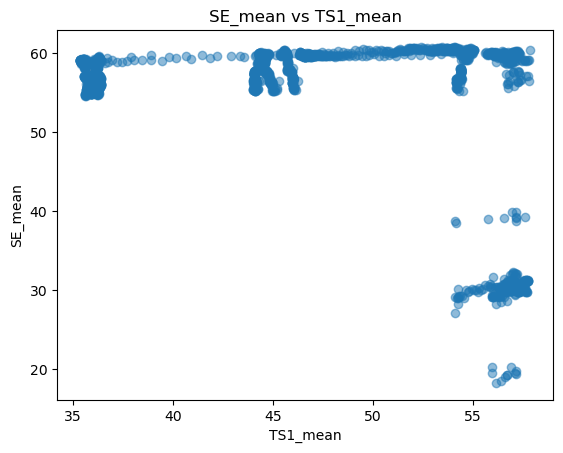

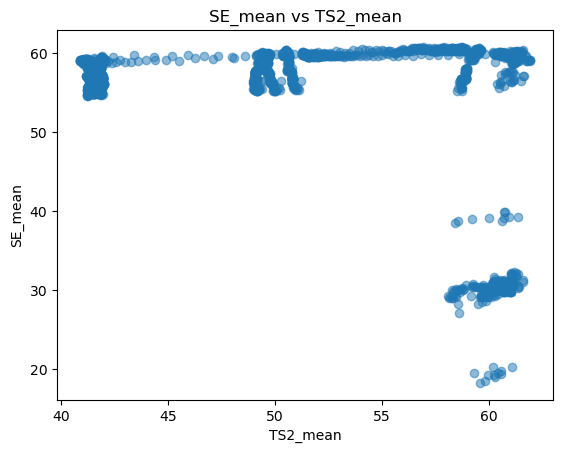

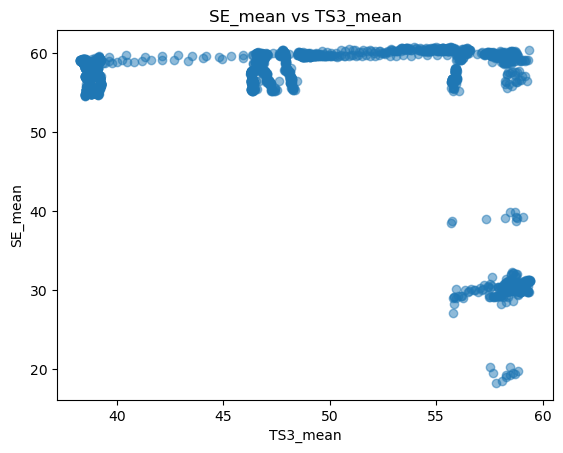

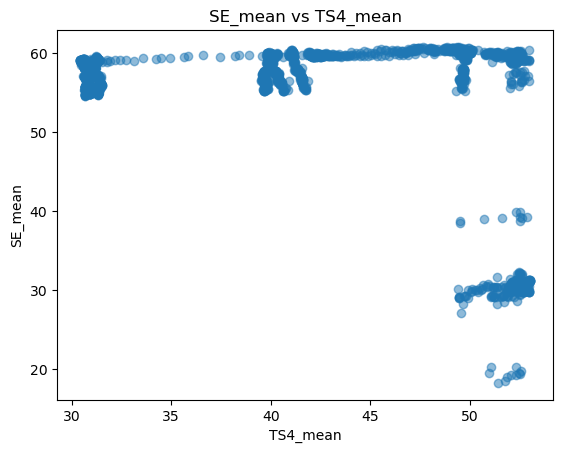

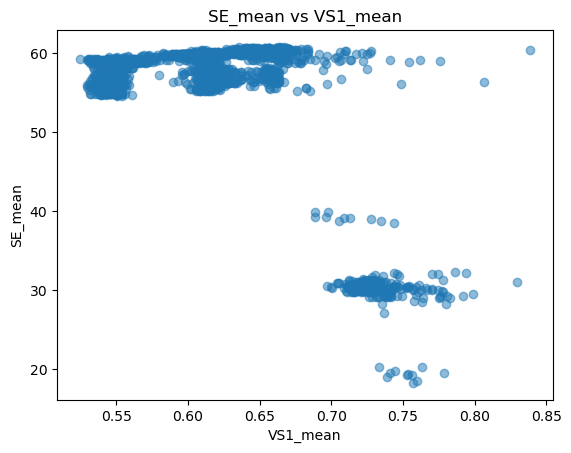

In [ ]:
# TODO Turn this into a Facet Grid.  Too much scrolling
# I will use some scatter plots to further understand the Pressure Sensors (PS), Volume Flow (FS), Motor Power (EPS), Temperature (TS) 
# and vibration (VS)
candidate_predictors = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
]

target = "SE_mean"   # change to CE_mean or CP_mean if preferred

for predictor in candidate_predictors:
    if predictor in model_data.columns and target in model_data.columns:
        plt.figure()
        plt.scatter(model_data[predictor], model_data[target], alpha=0.5)
        plt.title(f"{target} vs {predictor}")
        plt.xlabel(predictor)
        plt.ylabel(target)
        plt.savefig(visualization_dir / f"scatter_{target}_vs_{predictor}.png", bbox_inches="tight")
        plt.show()

In [46]:
# Explore some correlations
correlation_matrix = model_data.corr(numeric_only=True)

target_correlations = (
    correlation_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

target_correlations.head(20)

FS1_mean       0.994564
SE_median      0.987842
FS1_median     0.982133
PS2_std       -0.982045
PS1_median    -0.964948
PS2_mean      -0.957972
PS1_mean      -0.943953
EPS1_std      -0.938821
PS1_std       -0.930623
PS3_median     0.924183
EPS1_median   -0.913869
PS3_mean       0.884123
FS1_std       -0.847435
SE_std        -0.815188
VS1_median    -0.755926
SE_max        -0.722258
EPS1_mean     -0.677823
VS1_mean      -0.647300
PS2_median    -0.615667
PS1_max        0.574257
Name: SE_mean, dtype: float64

There are some good correlations, negative and positive, and I am a little surprised based on the scatter plots.  It looks like at least half of these are above 85%

In [47]:
target_correlations.to_csv(dataframe_dir / f"correlations_with_{target}.csv")

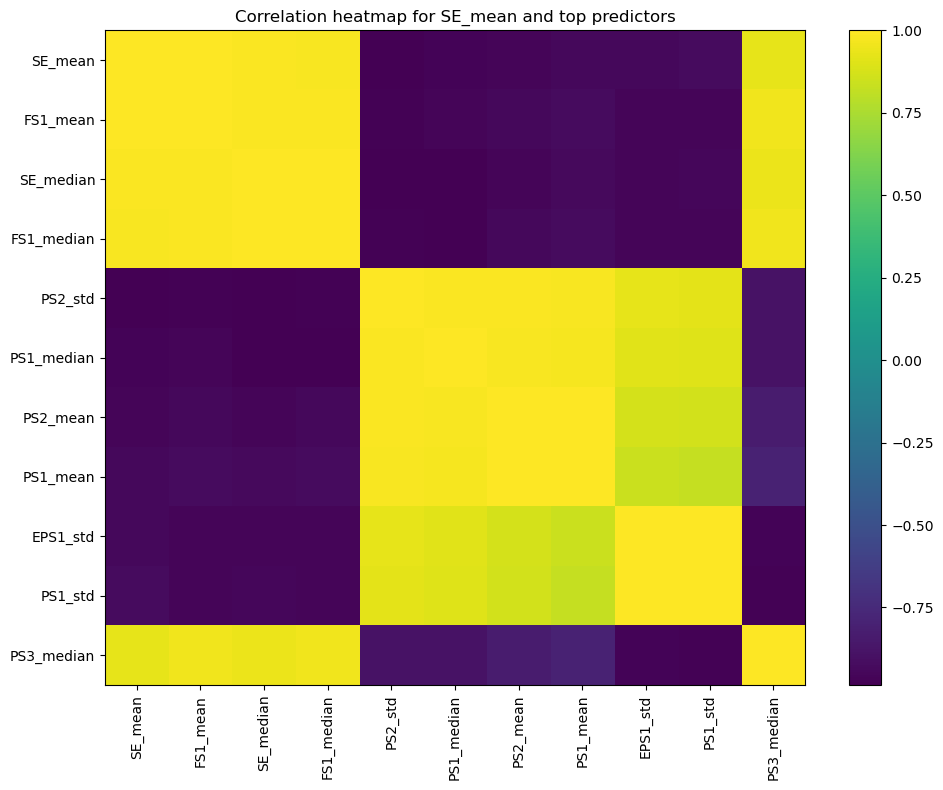

In [ ]:
# TODO choose a better color theme
# Correlation heatmap
top_features = target_correlations.head(10).index.tolist()
heatmap_data = model_data[[target] + top_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar()
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title(f"Correlation heatmap for {target} and top predictors")
plt.tight_layout()
plt.savefig(visualization_dir / f"correlation_heatmap_{target}.png", bbox_inches="tight")
plt.show()

Lots of correlations between predictors and other predictors as well as predictors and targets

In [49]:
# TODO - Rename targets so that they are easier to identify
# I want to see if I can visualize how the target changes when the system state changes
group_summary = model_data.groupby("cooler_condition")[target].agg(["count", "mean", "std", "min", "max"])
group_summary

,count,mean,std,min,max
cooler_condition,,,,,
3,732,49.830634,13.876032,18.276617,60.755300
20,732,58.341997,1.547146,55.148783,60.370467
100,741,57.661880,1.490691,54.581733,59.686233


In [50]:
group_summary.to_csv(dataframe_dir / f"{target}_by_cooler_condition.csv")

<Figure size 640x480 with 0 Axes>

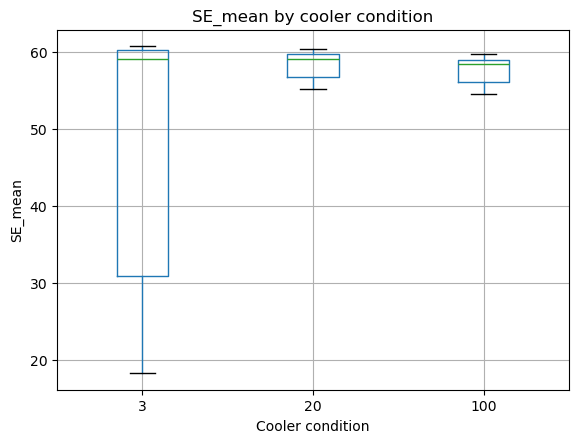

In [52]:
plt.figure()
model_data.boxplot(column=target, by="cooler_condition")
plt.title(f"{target} by cooler condition")
plt.suptitle("")
plt.xlabel("Cooler condition")
plt.ylabel(target)
plt.savefig(visualization_dir / f"boxplot_{target}_by_cooler_condition.png", bbox_inches="tight")
plt.show();

Interesting, I need to understand more about what these conditions mean.  Quite a tight range of values for 20 and 100 categories but the 3 is almost the entire range.


In [ ]:
# still exploring but I want to see more.
# Let's see if there is any linear between the system efficiency (SE) target and the predictor sensors.
# create a small dataset of these features and target
selected_target = "SE_mean"

selected_predictors = [
    "PS1_mean",
    "PS2_mean",
    "EPS1_mean",
    "FS1_mean",
    "TS1_mean",
    "VS1_mean"
]

regression_data = model_data[selected_predictors + [selected_target]].dropna()

regression_data.head()

,PS1_mean,PS2_mean,EPS1_mean,FS1_mean,TS1_mean,VS1_mean,SE_mean
0,160.673492,109.466914,2538.929167,6.709815,35.621983,0.576950,59.157183
1,160.603320,109.354890,2531.498900,6.715315,36.676967,0.565850,59.335617
2,160.347720,109.158845,2519.928000,6.718522,37.880800,0.576533,59.543150
3,160.188088,109.064807,2511.541633,6.720565,38.879050,0.569267,59.794900
4,160.000472,108.931434,2503.449500,6.690308,39.803917,0.577367,59.455267


In [55]:
regression_data.to_csv(PROCESSED_DIR / "linear_regression_ready_data.csv", index=False)

In [56]:
# TODO How did we normalize in the course?
# Normalize the predictor variables. Using z-score scaling which I have used successfully in my work
# I keep the original scale for the target
X = regression_data[selected_predictors]
y = regression_data[selected_target]

X_normalised = (X - X.mean()) / X.std()

regression_data_normalised = pd.concat([X_normalised, y], axis=1)

regression_data_normalised.head()



,PS1_mean,PS2_mean,EPS1_mean,FS1_mean,TS1_mean,VS1_mean,SE_mean
0,0.040043,0.017448,0.588054,0.494989,-1.226560,-0.603477,59.157183
1,0.025111,-0.005017,0.487423,0.500314,-1.094554,-0.787679,59.335617
2,-0.029279,-0.044331,0.330714,0.503419,-0.943923,-0.610391,59.543150
3,-0.063247,-0.063189,0.217134,0.505397,-0.819015,-0.730980,59.794900
4,-0.103171,-0.089936,0.107539,0.476103,-0.703290,-0.596562,59.455267


In [57]:
regression_data_normalised.to_csv(PROCESSED_DIR / "linear_regression_ready_data_normalised.csv", index=False)

This completes this stage of analysis.  I have completed all the preparation steps, and am well organized in the way I store my changed data.

Each sensor file was loaded, inspected and summarised into cycle-level features. The resulting processed dataset contains one row per operating cycle and numerical predictors derived from pressure, flow, temperature, vibration and motor power readings. 

Visual analysis and correlation analysis were then used to identify suitable predictor variables for a linear regression model. This preprocessing step transforms the original multi-file time-series dataset into a clean regression-ready table while preserving the engineering meaning of the original measurements.

# Part 4 - Statistical Analysis
## Statistical Summary of Key Series

Identify the key numerical series in the hydraulic systems dataset and describe their statistical characteristics. 

In Part 3, I summarised each sensor into cycle-level series such as mean, standard deviation, minimum and maximum. These cycle-level series are more suitable for linear regression because each row represents one operating cycle.

In this part (4) for each key series, I calculate measures of central tendency, measures of spread, skewness, kurtosis and an inferred distribution type. Visualisations are also used to support the interpretation of the statistical results.

In [69]:
# TODO Check kutosis and inferred distribution type in the course
# explore the model data created in Part 3
# The Linear Regression ready dataset from Part 3 is loaded. 
# Each row represents one 60-second hydraulic operating cycle. 
# Each column represents either a derived sensor feature, such as a cycle-level mean, or a condition variable from profile.txt.

print("Rows:", model_data.shape[0])
print("Columns:", model_data.shape[1])
model_data.head()

Rows: 2205
Columns: 90


,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
0,39.601350,6.370535,28.866,47.438,40.6755,1.862750,0.279385,1.383,2.188,1.9240,2538.929167,185.616121,2339.8,2951.6,2479.8,6.709815,3.015428,0.0,18.710,7.836,10.304592,0.091772,10.148,10.446,10.327,160.673492,13.939309,145.83,191.51,156.25,109.466914,47.114508,0.0,156.99,129.365,1.991475,0.945705,0.0,10.039,2.297,0.0,0.0,0.0,0.0,0.0,9.842170,0.088154,9.681,10.016,9.844,9.728097,0.085366,9.568,9.887,9.733,59.157183,23.763984,0.0,79.568,68.5145,35.621983,0.308230,35.156,36.152,35.5720,40.978767,0.154302,40.773,41.250,40.9630,38.471017,0.084659,38.316,38.613,38.4960,31.745250,1.116478,30.363,33.594,31.576,0.576950,0.027078,0.532,0.624,0.5770,3,100,0,130,1
1,25.786433,1.686129,23.320,29.208,25.3855,1.255550,0.074605,1.147,1.414,1.2340,2531.498900,189.940089,2332.0,2947.4,2470.0,6.715315,3.006248,0.0,18.712,7.853,10.403098,0.019162,10.352,10.453,10.403,160.603320,14.118967,145.73,191.47,156.06,109.354890,47.045611,0.0,157.56,129.385,1.976234,0.941967,0.0,9.992,2.273,0.0,0.0,0.0,0.0,0.0,9.635142,0.038392,9.557,9.745,9.632,9.529488,0.036316,9.454,9.637,9.526,59.335617,23.857918,0.0,80.441,68.5360,36.676967,0.585740,35.648,37.488,36.7675,41.532767,0.338234,41.031,42.105,41.5180,38.978967,0.176921,38.668,39.254,38.9845,34.493867,0.435312,33.648,35.148,34.553,0.565850,0.027241,0.524,0.626,0.5595,3,100,0,130,1
2,22.218233,0.638345,21.220,23.554,22.1040,1.113217,0.023263,1.076,1.159,1.1095,2519.928000,190.736850,2318.6,2939.8,2457.4,6.718522,3.014248,0.0,18.698,7.847,10.366250,0.026361,10.296,10.443,10.367,160.347720,14.192619,145.37,191.41,155.72,109.158845,46.992060,0.0,156.97,129.325,1.972224,0.943501,0.0,10.914,2.273,0.0,0.0,0.0,0.0,0.0,9.530548,0.035817,9.455,9.640,9.528,9.427949,0.036031,9.348,9.536,9.425,59.543150,23.923381,0.0,80.824,68.8530,37.880800,0.559169,36.879,38.621,38.0235,42.442450,0.390588,41.832,43.039,42.4235,39.631950,0.251133,39.234,40.062,39.6270,35.646150,0.293889,35.098,36.141,35.635,0.576533,0.036729,0.529,0.662,0.5620,3,100,0,130,1
3,20.459817,0.455755,19.673,21.565,20.4805,1.062150,0.024621,1.022,1.107,1.0660,2511.541633,191.270607,2310.8,2929.6,2448.0,6.720565,3.020176,0.0,18.896,7.843,10.302678,0.026750,10.241,10.382,10.302,160.188088,14.227803,145.14,191.34,155.56,109.064807,46.972221,0.0,156.44,128.865,1.946575,0.935534,0.0,10.297,2.242,0.0,0.0,0.0,0.0,0.0,9.438827,0.037069,9.363,9.535,9.436,9.337430,0.037375,9.257,9.431,9.335,59.794900,24.023005,0.0,80.930,69.0060,38.879050,0.516176,37.887,39.473,39.0550,43.403983,0.398476,42.805,43.988,43.3650,40.403383,0.285434,40.023,40.934,40.3420,36.579467,0.262397,36.105,36.988,36.635,0.569267,0.033464,0.527,0.645,0.5550,3,100,0,130,1
4,19.787017,0.290156,19.133,20.460,19.7985,1.070467,0.021477,1.016,1.106,1.0725,2503.449500,191.258369,2301.8,2923.8,2440.6,6.690308,3.011550,0.0,18.876,7.831,10.237750,0.029170,10.179,10.312,10.236,160.000472,14.276434,144.95,191.41,155.34,108.931434,46.874946,0.0,158.13,129.000,1.922707,0.930335,0.0,11.102,2.219,0.0,0.0,0.0,0.0,0.0,9.358762,0.029779,9.290,9.443,9.358,9.260636,0.028592,9.195,9.342,9.260,59.455267,23.972262,0.0,81.100,69.0130,39.803917,0.535374,38.789,40.391,39.9670,44.332750,0.372769,43.742,44.887,44.3355,41.31055

In [ ]:
# in part 3 I created a list of 'candidate sensors'.  Here I create the actual sensors list that will be used from here on.

key_series = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean",
    "CE_mean", "CP_mean", "SE_mean"
]

key_series = [col for col in key_series if col in model_data.columns]

print("Key series available:")
for col in key_series:
    print(col)

Key series available:
PS1_mean
PS2_mean
PS3_mean
PS4_mean
PS5_mean
PS6_mean
EPS1_mean
FS1_mean
FS2_mean
TS1_mean
TS2_mean
TS3_mean
TS4_mean
VS1_mean
CE_mean
CP_mean
SE_mean


In [ ]:
# TODO How did we normalize in the course?
# Normalize the predictor variables. Using z-score scaling which I have used successfully in my work
# I keep the original scale for the target
features = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
    ]

targets = ["CE_mean", "CP_mean", "SE_mean"]

regression_data = model_data[features + targets].dropna()

regression_data.head()


X = regression_data[features]
y = regression_data[targets]

X_normalised = (X - X.mean()) / X.std()

regression_data_normalised = pd.concat([X_normalised, y], axis=1)

regression_data_normalised.head()


,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,CE_mean,CP_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,39.601350,1.862750,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,25.786433,1.255550,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,22.218233,1.113217,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,20.459817,1.062150,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,19.787017,1.070467,59.455267


The summary function in the cell below calculates measures of central tendency using the mean and median. It calculates measures of spread using standard deviation, variance, range and interquartile range. Skewness is used to describe whether the data is balanced, right-skewed or left-skewed. Kurtosis is used to describe whether the distribution has normal-like, heavy or flat tails.

In [83]:
# Create statistical summary function
def classify_distribution(skewness, kurtosis):
    """
    Classifies the approximate distribution shape using skewness and kurtosis.
    Kurtosis is interpreted using Fisher's definition, where 0 is close to normal.
    """
    if abs(skewness) < 0.5:
        skew_label = "approximately symmetric"
    elif skewness >= 0.5:
        skew_label = "right-skewed"
    else:
        skew_label = "left-skewed"
    
    if kurtosis > 1:
        tail_label = "heavy-tailed"
    elif kurtosis < -1:
        tail_label = "light-tailed or flat"
    else:
        tail_label = "normal-like tails"
    
    return f"{skew_label}, {tail_label}"


def summarise_series(series, series_name):
    """
    Produces a statistical summary for one numerical series.
    """
    clean_series = pd.to_numeric(series, errors="coerce").dropna()
    
    if len(clean_series) == 0:
        return {
            "series": series_name,
            "count": 0
        }
    
    mean_value = clean_series.mean()
    median_value = clean_series.median()
    std_value = clean_series.std()
    variance_value = clean_series.var()
    min_value = clean_series.min()
    max_value = clean_series.max()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1
    data_range = max_value - min_value
    skewness = stats.skew(clean_series)
    kurtosis = stats.kurtosis(clean_series)  # Fisher=True by default
    
    return {
        "series": series_name,
        "count": len(clean_series),
        "mean": mean_value,
        "median": median_value,
        "std_dev": std_value,
        "variance": variance_value,
        "min": min_value,
        "q1": q1,
        "q3": q3,
        "max": max_value,
        "range": data_range,
        "iqr": iqr,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "distribution_type": classify_distribution(skewness, kurtosis)
    }

In [87]:
# Create a statistical summary table
# This table directly supports the coursework requirement to report central tendency, spread, skewness, kurtosis and distribution type.
summary_rows = []

for col in key_series:
    summary_rows.append(summarise_series(regression_data[col], col))

summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.round(4)

summary_df

,series,count,mean,median,std_dev,variance,min,q1,q3,max,range,iqr,skewness,kurtosis,distribution_type
0,PS1_mean,2205,160.4853,158.9609,4.6994,22.0846,155.3915,158.1002,161.0007,180.9227,25.5312,2.9005,2.0994,3.6797,"right-skewed, heavy-tailed"
1,PS2_mean,2205,109.3799,107.7302,4.9866,24.8660,104.4063,106.9624,109.4216,131.5891,27.1828,2.4592,2.2861,4.1995,"right-skewed, heavy-tailed"
2,PS3_mean,2205,1.7532,1.7796,0.2519,0.0635,0.8403,1.7297,1.9320,2.0234,1.1831,0.2023,-1.7100,2.3906,"left-skewed, heavy-tailed"
3,PS4_mean,2205,2.6003,0.0000,4.2794,18.3129,0.0000,0.0000,3.5033,10.2071,10.2071,3.5033,1.1473,-0.6372,"right-skewed, normal-like tails"
4,PS5_mean,2205,9.1633,9.1158,0.5763,0.3321,8.3658,8.5472,9.8444,9.9785,1.6127,1.2971,0.1504,-1.4620,"approximately symmetric, light-tailed or flat"
5,PS6_mean,2205,9.0794,9.0315,0.5496,0.3020,8.3215,8.4872,9.7293,9.8566,1.5351,1.2421,0.1528,-1.4628,"approximately symmetric, light-tailed or flat"
6,EPS1_mean,2205,2495.5092,2480.9266,73.8367,5451.8556,2361.7473,2442.9335,2548.2115,2740.6410,378.8937,105.2780,0.2235,-0.6804,"approximately symmetric, normal-like tails"
7,FS1_mean,2205,6.1985,6.5767,1.0329,1.0668,2.0186,6.3917,6.6575,6.7227,4.7041,0.2658,-2.5078,4.5659,"left-skewed, heavy-tailed"
8,FS2_mean,2205,9.6495,9.6923,0.4492,0.2018,8.8575,9.2034,10.1550,10.4031,1.5456,0.9516,-0.2434,-1.2713,"approximately symmetric, light-tailed or flat"
9,TS1_mean,2205,45.4246,44.8366,7.9919,63.8710,35.3138,36.2372,54.1043,57.8993,22.5855,17.8672,0.1087,-1.4105,"approximately symmetric, light-tailed or flat"


In [88]:
summary_df.to_csv(dataframe_dir / "key_series_statistical_summary.csv", index=False)

In [89]:
# Sort by skewness and kurtosis
# Sorting by skewness helps identify variables where the mean and median may differ noticeably. 
# Sorting by kurtosis helps identify variables with unusually heavy tails or flat distributions. 

# Note: the key=abs parameter.  If you just glance at the list you will see that the order visually does
# not correspond with what you are expecting and the reason for this is that the sorted columns are
# in absolute values and not their actual values.

summary_by_skewness = summary_df.sort_values("skewness", key=abs, ascending=False)
summary_by_kurtosis = summary_df.sort_values("kurtosis", key=abs, ascending=False)

display(summary_by_skewness[["series", "mean", "median", "std_dev", "skewness", "kurtosis", "distribution_type"]])
display(summary_by_kurtosis[["series", "mean", "median", "std_dev", "skewness", "kurtosis", "distribution_type"]])

,series,mean,median,std_dev,skewness,kurtosis,distribution_type
7,FS1_mean,6.1985,6.5767,1.0329,-2.5078,4.5659,"left-skewed, heavy-tailed"
16,SE_mean,55.2879,58.7582,8.9602,-2.4369,4.3799,"left-skewed, heavy-tailed"
1,PS2_mean,109.3799,107.7302,4.9866,2.2861,4.1995,"right-skewed, heavy-tailed"
0,PS1_mean,160.4853,158.9609,4.6994,2.0994,3.6797,"right-skewed, heavy-tailed"
2,PS3_mean,1.7532,1.7796,0.2519,-1.7100,2.3906,"left-skewed, heavy-tailed"
3,PS4_mean,2.6003,0.0000,4.2794,1.1473,-0.6372,"right-skewed, normal-like tails"
13,VS1_mean,0.6133,0.6102,0.0603,0.7190,-0.0522,"right-skewed, normal-like tails"
14,CE_mean,31.2991,27.3925,11.5753,0.4639,-1.5075,"approximately symmetric, light-tailed or flat"
15,CP_mean,1.8084,1.7397,0.2783,0.3041,-0.9785,"approximately symmetric, normal-like tails"
8,FS2_mean,9.6495,9.6923,0.4492,-0.2434,-1.2713,"approximately symmetric, light-tailed or flat"


,series,mean,median,std_dev,skewness,kurtosis,distribution_type
7,FS1_mean,6.1985,6.5767,1.0329,-2.5078,4.5659,"left-skewed, heavy-tailed"
16,SE_mean,55.2879,58.7582,8.9602,-2.4369,4.3799,"left-skewed, heavy-tailed"
1,PS2_mean,109.3799,107.7302,4.9866,2.2861,4.1995,"right-skewed, heavy-tailed"
0,PS1_mean,160.4853,158.9609,4.6994,2.0994,3.6797,"right-skewed, heavy-tailed"
2,PS3_mean,1.7532,1.7796,0.2519,-1.7100,2.3906,"left-skewed, heavy-tailed"
14,CE_mean,31.2991,27.3925,11.5753,0.4639,-1.5075,"approximately symmetric, light-tailed or flat"
5,PS6_mean,9.0794,9.0315,0.5496,0.1528,-1.4628,"approximately symmetric, light-tailed or flat"
4,PS5_mean,9.1633,9.1158,0.5763,0.1504,-1.4620,"approximately symmetric, light-tailed or flat"
10,TS2_mean,50.3660,49.7806,7.3963,0.0879,-1.4347,"approximately symmetric, light-tailed or flat"
12,TS4_mean,40.7357,40.4290,8.1079,0.0576,-1.4182,"approximately symmetric, light-tailed or flat"


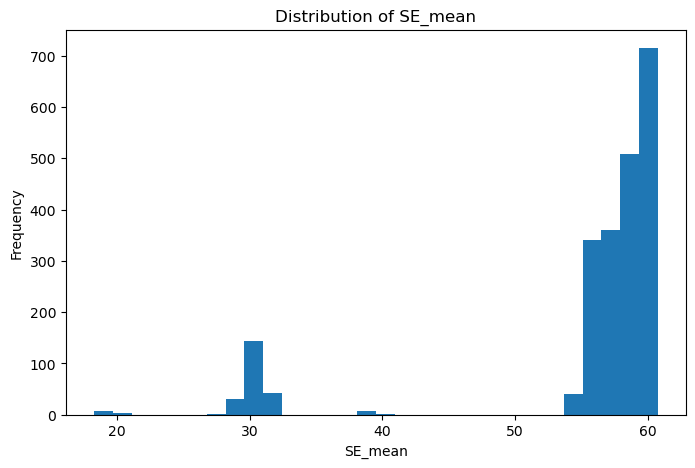

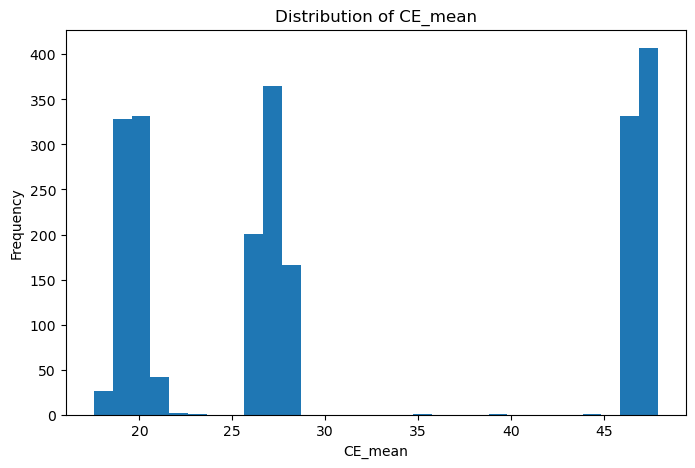

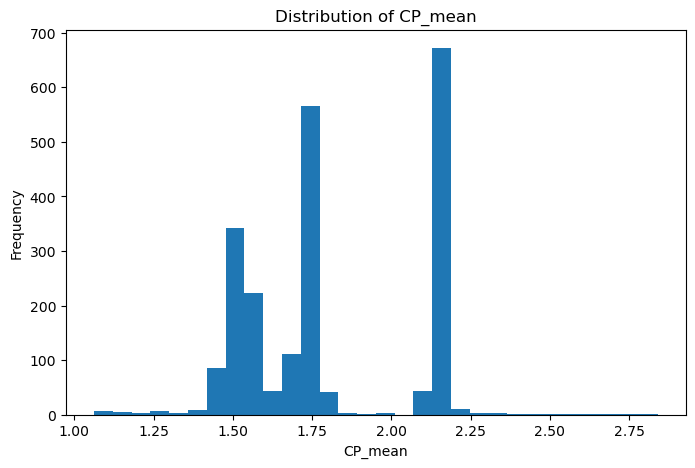

In [90]:
# Target variable histograms
# Visualizations are not meant until Part 5 but they are a very useful tool when
# exploring statistical data
target_candidates = ["SE_mean", "CE_mean", "CP_mean"]

for col in target_candidates:
    if col in regression_data.columns:
        plt.figure(figsize=(8, 5))
        plt.hist(regression_data[col].dropna(), bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.savefig(visualization_dir / f"histogram_{col}.png", bbox_inches="tight")
        plt.show()

From the above histograms, and as per Part 3, there are clusters apparent in the target data

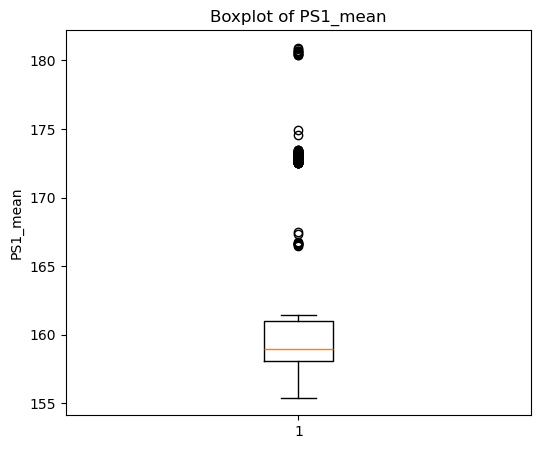

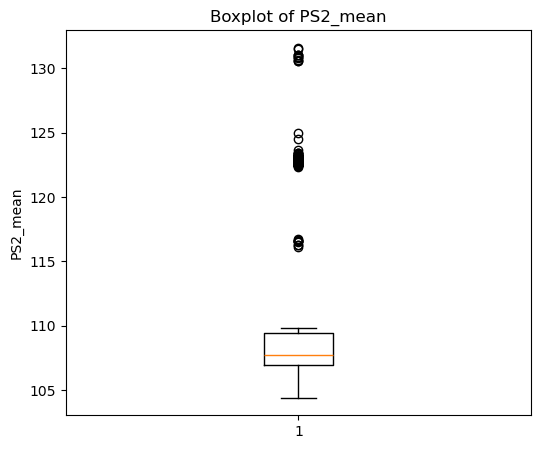

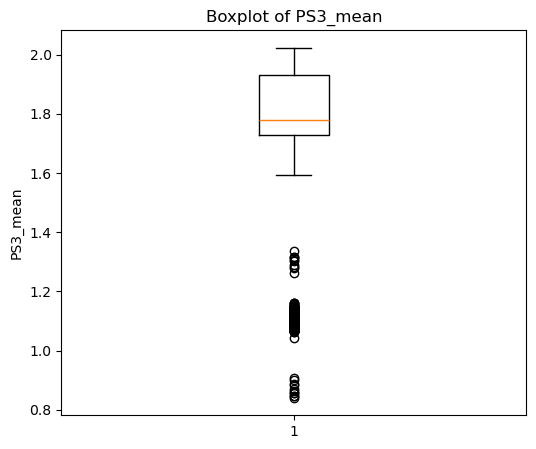

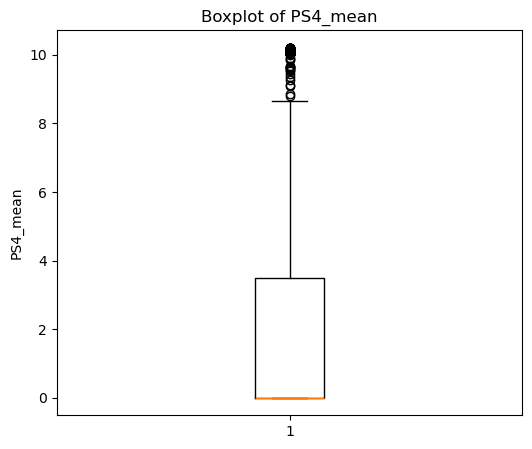

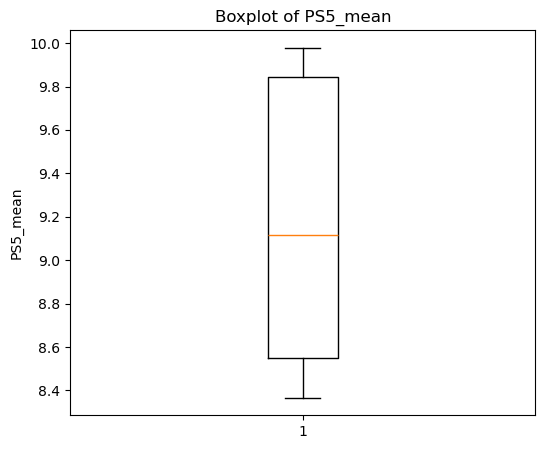

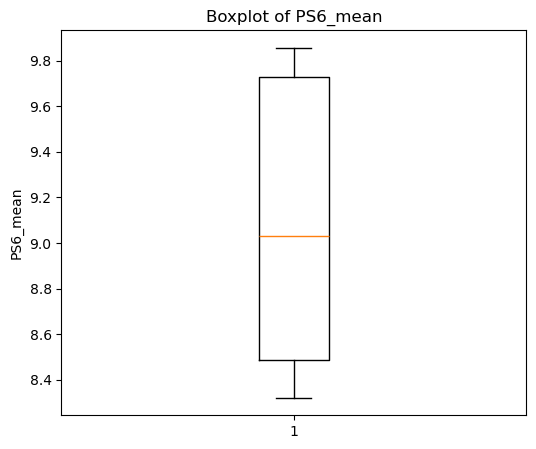

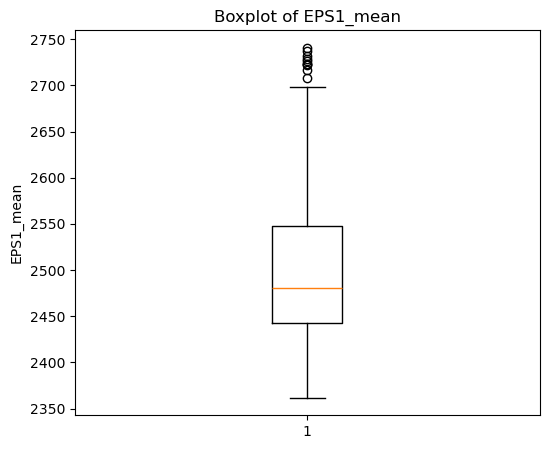

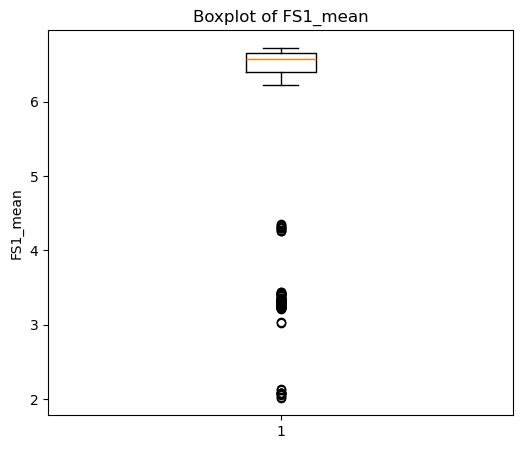

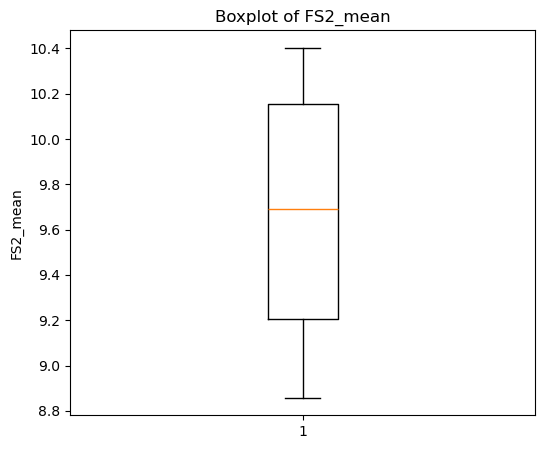

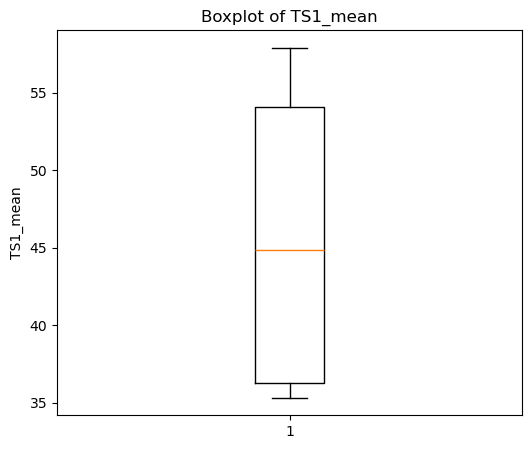

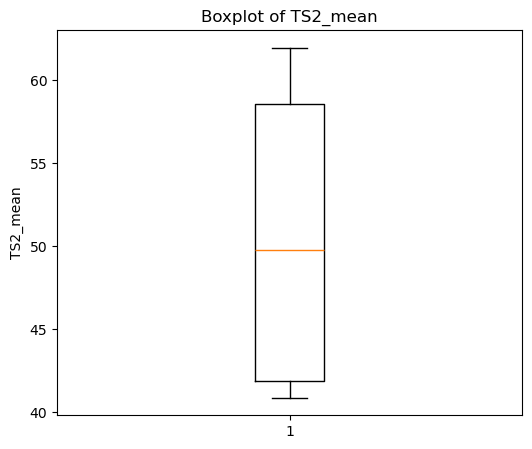

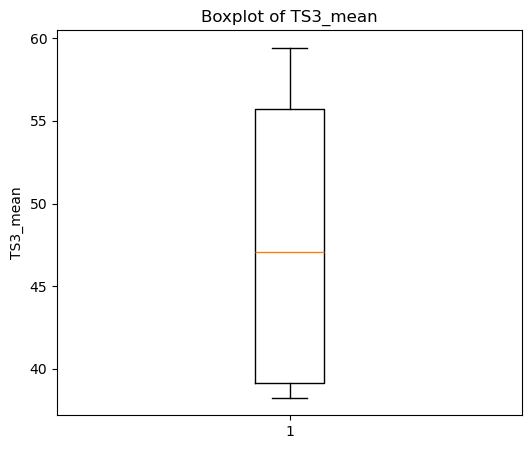

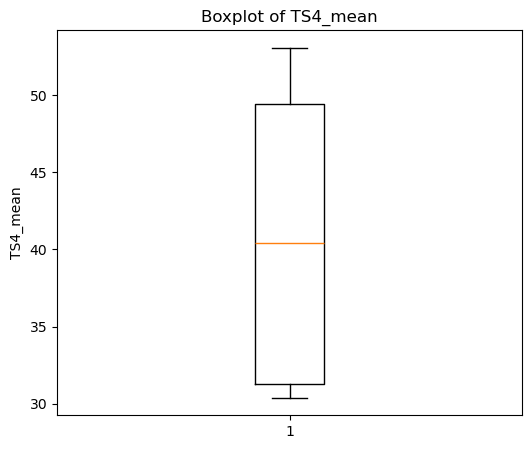

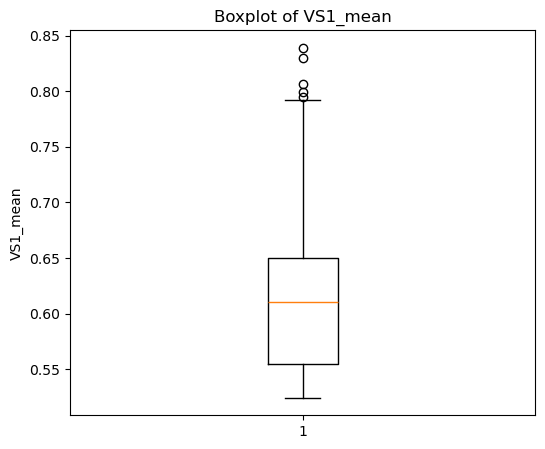

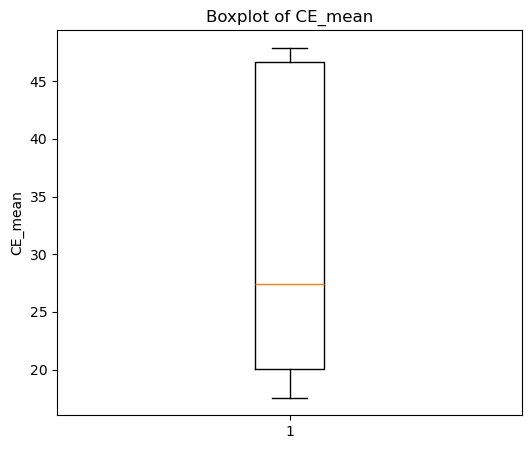

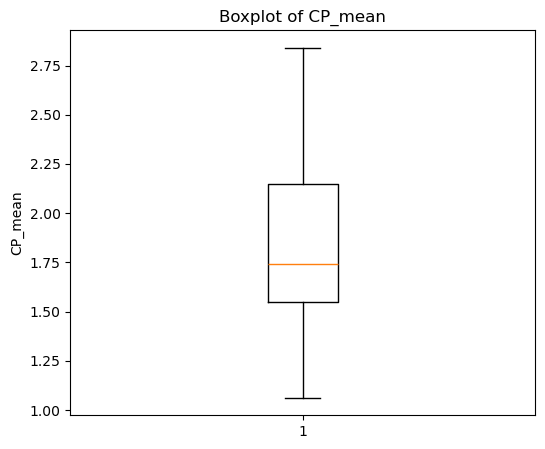

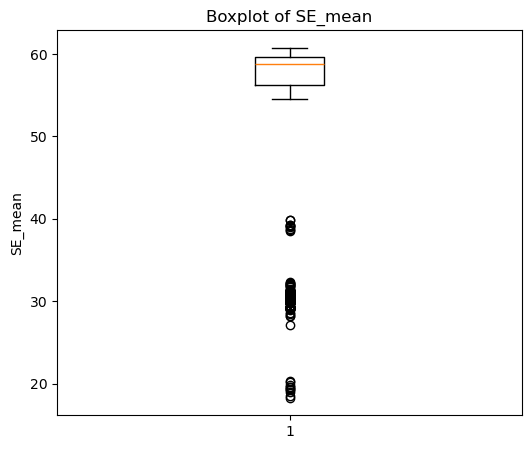

In [ ]:
# Lets check outliers using boxplots
# Boxplots are used to inspect spread, median position and possible outliers. 
# They are useful because standard deviation alone can be affected by extreme values. 
# The interquartile range and median shown in the boxplot provide a more robust view of the typical behaviour of each sensor series.
# TODO Facet these
for col in key_series:
    plt.figure(figsize=(6, 5))
    plt.boxplot(regression_data[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.savefig(visualization_dir / f"boxplot_{col}.png", bbox_inches="tight")
    plt.show()

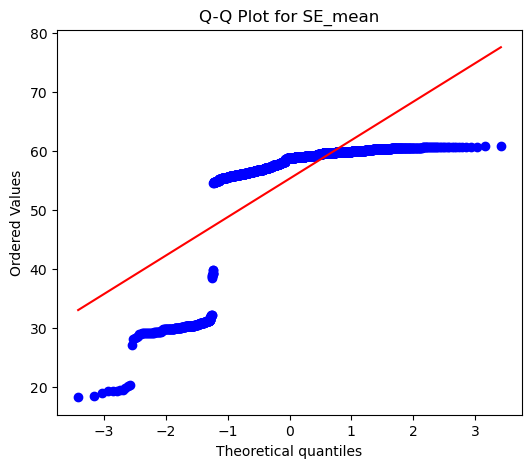

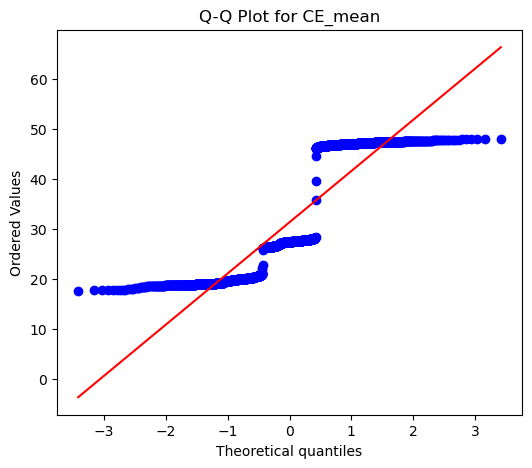

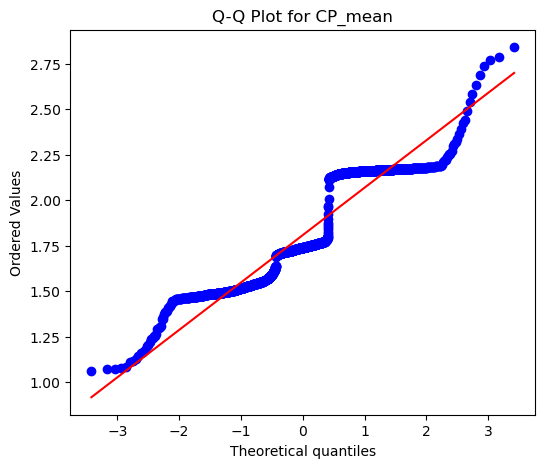

In [ ]:
# Q-Q plots
# Q-Q plots compare the observed data against a theoretical normal distribution. 
# If the points follow the diagonal line closely, the series is approximately normal. 
# Curved patterns suggest skewness or heavy tails. 
# This is useful because linear regression does not require every predictor to be normally distributed, 
# but strongly skewed variables or extreme outliers can affect model interpretation and error behaviour.

# TODO Reference course work
for col in target_candidates:
    if col in regression_data.columns:
        clean_series = model_data[col].dropna()
        
        plt.figure(figsize=(6, 5))
        stats.probplot(clean_series, dist="norm", plot=plt)
        plt.title(f"Q-Q Plot for {col}")
        plt.savefig(visualization_dir / f"qqplot_{col}.png", bbox_inches="tight")
        plt.show()

In [ ]:
# Compare median and mean
# The comparison between mean and median helps identify whether the mean is a reliable description of the typical value. 
# When the mean and median are close together, the distribution is likely more balanced. When they differ noticeably, the median may be more informative because it is less affected by skewness and extreme values.
summary_df["mean_minus_median"] = summary_df["mean"] - summary_df["median"]
summary_df["absolute_mean_median_difference"] = summary_df["mean_minus_median"].abs()

mean_median_comparison = summary_df.sort_values(
    "absolute_mean_median_difference", 
    ascending=False
)

mean_median_comparison[
    ["series", "mean", "median", "mean_minus_median", "skewness", "distribution_type"]
]

,series,mean,median,mean_minus_median,skewness,distribution_type
6,EPS1_mean,2495.5092,2480.9266,14.5826,0.2235,"approximately symmetric, normal-like tails"
14,CE_mean,31.2991,27.3925,3.9066,0.4639,"approximately symmetric, light-tailed or flat"
16,SE_mean,55.2879,58.7582,-3.4703,-2.4369,"left-skewed, heavy-tailed"
3,PS4_mean,2.6003,0.0000,2.6003,1.1473,"right-skewed, normal-like tails"
1,PS2_mean,109.3799,107.7302,1.6497,2.2861,"right-skewed, heavy-tailed"
0,PS1_mean,160.4853,158.9609,1.5244,2.0994,"right-skewed, heavy-tailed"
11,TS3_mean,47.6621,47.0703,0.5918,0.1228,"approximately symmetric, light-tailed or flat"
9,TS1_mean,45.4246,44.8366,0.5880,0.1087,"approximately symmetric, light-tailed or flat"
10,TS2_mean,50.3660,49.7806,0.5854,0.0879,"approximately symmetric, light-tailed or flat"
7,FS1_mean,6.1985,6.5767,-0.3782,-2.5078,"left-skewed, heavy-tailed"


# Summary - REVIEW

The statistical summary shows that the dataset contains multiple numerical series with different distribution shapes. For approximately symmetric variables, the mean and median are close together, so the mean is a useful measure of central tendency. For skewed variables, the median is more informative because it is less affected by extreme values. Standard deviation and interquartile range show how much variation exists across operating cycles. Variables with high standard deviation or high interquartile range may be more useful for regression because they contain more variation for the model to explain.

Skewness and kurtosis add further insight. Skewness indicates whether values are concentrated on one side of the distribution, while kurtosis indicates whether the distribution has unusually heavy or flat tails. Series with high skewness or kurtosis should be inspected carefully because they may represent changing operating conditions, outliers or component degradation. For this project, the most important series are the efficiency-related variables, especially SE_mean, because the project objective is to predict hydraulic efficiency from sensor data. The most interesting predictors are likely to be the pressure, flow, temperature, vibration and motor power variables that show meaningful spread and a visible relationship with the efficiency target.

# Most interesting measure and why
# REVIEW
The most interesting measures are skewness and the difference between the mean and median. This is because the project is concerned with predicting hydraulic efficiency, and skewed sensor variables may indicate that the system does not behave the same way across all operating cycles. If a predictor has strong skewness, the median may better describe normal operation than the mean. Similarly, if an efficiency variable such as SE_mean is highly skewed, a linear regression model may need careful interpretation because the model may fit the dominant operating condition better than the less common degraded conditions.

# Final Conclusion for Part 4
# REVIEW
The key series selected for statistical analysis were the cycle-level means for pressure, flow, temperature, vibration, motor power and efficiency variables. These were selected because they represent the main physical behaviour of the hydraulic system and are suitable for later linear regression. For each series, the mean and median were used to describe central tendency, while standard deviation, variance, range and interquartile range were used to describe spread. Skewness and kurtosis were calculated to assess distribution shape. Variables where the mean and median were close together were interpreted as approximately balanced, while variables with larger differences were treated as skewed. In this dataset, the median and interquartile range are particularly useful because sensor readings may be affected by different operating conditions and occasional extreme values. Skewness and kurtosis are also important because highly skewed or heavy-tailed variables may affect the reliability and interpretation of a linear regression model.

In [ ]:
# At PArt 5 Visualization

In [ ]:
# NOTE WORKING WITH regression_data which is normalized, not model_data!!!!!